# CREATOR COMPASS EDA: Engagement Prediction

## Part 1: Data Quality Assessment

**Goal:** Ensure data is clean, reliable, and ready for analysis

### Step 1.1: Load and Inspect Data

Load the combined dataset and verify basic properties

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11


In [4]:
# Load the combined training dataset
df = pd.read_csv('../../data/processed/combined_training.csv', low_memory=False)

# Basic dataset information

print("DATASET OVERVIEW")

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print("\n" + "="*70)

DATASET OVERVIEW
Dataset shape: 82,476 rows × 31 columns
Memory usage: 69.8 MB



In [5]:
# Display first 5 rows
df.head()

,content_id,platform,category,caption,caption_length,hashtag_count,hashtags,duration_sec,views,likes,...,posting_month,posting_year,sentiment,has_emoji,emoji_count,has_call_to_action,has_question,word_count,trend_label,data_source
0,7606525547610524942,tiktok,general,#rich #richlifestyle #penthouse,32,3,"['rich', 'richlifestyle', 'penthouse']",28.0,377800,61200,...,2,2026,neutral,False,0.0,False,0.0,3.0,NaN,scraped_apify
1,7597408819181931797,tiktok,general,Better late than never 👌🏽✨☁️ #lilbro #lifestyl...,73,5,"['lilbro', 'lifestyle', 'fyp', 'gamer', 'dayin...",170.0,1700000,158500,...,1,2026,neutral,True,1.0,False,0.0,10.0,NaN,scraped_apify
2,7366355450830261509,tiktok,general,If you need some content ideas and tips to gro...,234,8,"['contentcreatortips', 'greenscreen', 'content...",173.0,1400000,107600,...,5,2024,neutral,True,2.0,True,0.0,28.0,NaN,scraped_apify
3,7604229327680556321,tiktok,general,#money #rich #lifestyle #motivation #luxury,44,5,"['money', 'rich', 'lifestyle', 'motivation', '...",21.0,387400,68300,...,2,2026,neutral,False,0.0,False,0.0,5.0,NaN,scraped_apify
4,7600840983827189022,tiktok,general,#contentideas well more of a reframing how we ...,115,4,"['contentideas', 'lifestylecontent', 'stopover...",569.0,344200,52300,...,1,2026,neutral,False,0.0,False,0.0,13.0,NaN,scraped_apify


In [6]:
# Check data types
print("Data Types:")

print(df.dtypes)


Data Types:
content_id                 object
platform                   object
category                   object
caption                    object
caption_length              int64
hashtag_count               int64
hashtags                   object
duration_sec              float64
views                       int64
likes                       int64
comments                    int64
shares                      int64
saves                       int64
engagement_rate           float64
engagement_score          float64
engagement_rating          object
creator_username           object
creator_follower_count    float64
creator_verified          float64
posting_hour                int64
posting_day                object
posting_month               int64
posting_year                int64
sentiment                  object
has_emoji                  object
emoji_count               float64
has_call_to_action         object
has_question              float64
word_count                float64
tr

In [7]:
# Basic statistical summary
print("Statistical Summary of Numerical Features:")
df.describe().T

Statistical Summary of Numerical Features:


,count,mean,std,min,25%,50%,75%,max
caption_length,82476.0,65.296244,7.459886e+01,0.0,22.000000,28.0000,116.0000,3.377000e+03
hashtag_count,82476.0,3.813546,3.972694e+00,0.0,1.000000,1.0000,7.0000,7.700000e+01
duration_sec,52477.0,36.008175,3.560322e+01,0.0,22.000000,31.0000,43.0000,3.600000e+03
views,82476.0,288122.561048,3.273101e+06,12.0,6495.750000,27883.0000,85227.2500,4.392000e+08
likes,82476.0,20187.797638,2.239416e+05,0.0,286.000000,1399.5000,4681.2500,1.650000e+07
comments,82476.0,481.238457,1.980888e+03,0.0,9.000000,131.0000,463.0000,2.484000e+05
shares,82476.0,2076.219700,3.843227e+04,0.0,15.000000,126.0000,439.0000,5.900000e+06
saves,82476.0,2479.080811,3.030712e+04,0.0,38.000000,135.0000,457.0000,3.832277e+06
engagement_rate,82476.0,0.638536,3.001328e+00,0.0,0.040500,0.0606,0.0867,8.151408e+01
engagement_score,82476.0,4.626778,1.912083e+00,0.0,3.044575,4.8515,6.1701,1.584067e+01


### Step 1.2: Missing Data Analysis

Identify missing values and decide on handling strategy

In [8]:
# Calculate missing data summary
missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Percent', ascending=False)

# Filter to show only columns with missing values
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]


print("Missing Dat Summary ")

print(missing_summary)
print(f"\nTotal columns with missing data: {len(missing_summary)}")


Missing Dat Summary 
                        Missing_Count  Missing_Percent
creator_verified                78078            94.67
sentiment                       78078            94.67
emoji_count                     78078            94.67
word_count                      78078            94.67
has_question                    78078            94.67
creator_follower_count          48079            58.29
has_call_to_action              48079            58.29
trend_label                     34397            41.71
caption                         30025            36.40
duration_sec                    29999            36.37
hashtags                        29999            36.37
has_emoji                       29999            36.37

Total columns with missing data: 12


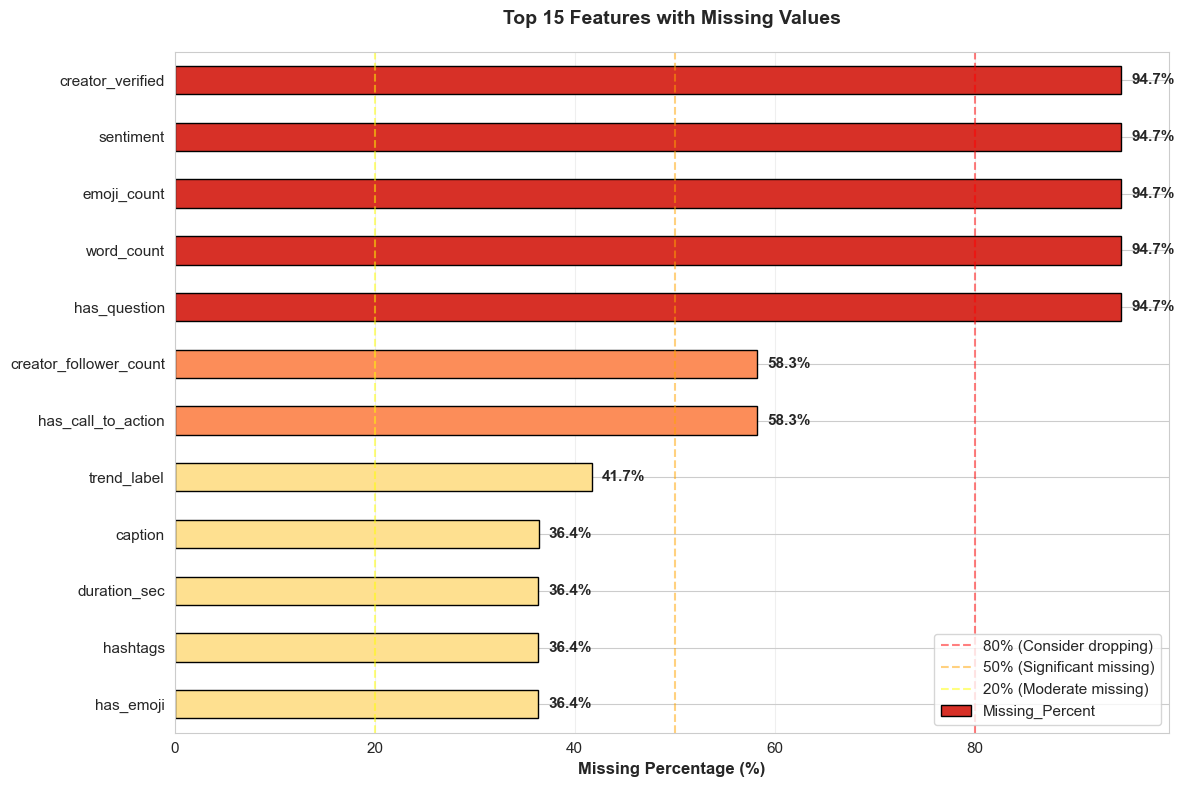

In [9]:
# Visualize missing data
fig, ax = plt.subplots(figsize=(12, 8))

# Plot top 15 features with missing values
top_missing = missing_summary.head(15)
colors = ['#d73027' if x > 80 else '#fc8d59' if x > 50 else '#fee090' if x > 20 else '#91bfdb' 
          for x in top_missing['Missing_Percent']]

top_missing['Missing_Percent'].plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_xlabel('Missing Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Features with Missing Values', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()

# Add percentage labels
for i, v in enumerate(top_missing['Missing_Percent']):
    ax.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

# Add threshold lines
ax.axvline(80, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='80% (Consider dropping)')
ax.axvline(50, color='orange', linestyle='--', alpha=0.5, linewidth=1.5, label='50% (Significant missing)')
ax.axvline(20, color='yellow', linestyle='--', alpha=0.5, linewidth=1.5, label='20% (Moderate missing)')

ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# check critical features

# Check to see if any key features are missing 
print("\nKEY FEATURES:")
key_features = ['views', 'likes', 'comments', 'shares', 'saves', 'caption_length', 'hashtag_count']
for feature in key_features:
    if feature in df.columns:
        missing = df[feature].isnull().sum()
        pct = (missing / len(df) * 100)
        print(f"{feature}: {missing} missing ({pct:.2f}%)")




KEY FEATURES:
views: 0 missing (0.00%)
likes: 0 missing (0.00%)
comments: 0 missing (0.00%)
shares: 0 missing (0.00%)
saves: 0 missing (0.00%)
caption_length: 0 missing (0.00%)
hashtag_count: 0 missing (0.00%)


### Step 1.3: Duplicate Detection

Check for duplicate content IDs and potential bot/spam patterns

In [11]:
# Check for duplicate content IDs

n_duplicate_ids = df.duplicated(subset=['content_id']).sum()
pct_duplicate = (n_duplicate_ids / len(df)) * 100

print(f"\nDuplicate content_ids: {n_duplicate_ids} ({pct_duplicate:.2f}%)")

if n_duplicate_ids > 0:
    print("\n Warning: Found duplicate content IDs!")
    # Show a sample
    duplicate_ids = df[df.duplicated(subset=['content_id'], keep=False)].sort_values('content_id')
    print(f"\nSample of duplicate records (first 5):")
    print(duplicate_ids[['content_id', 'platform', 'category', 'views', 'engagement_score']].head())
else:
    print("No duplicate content IDs found")



Duplicate content_ids: 0 (0.00%)
No duplicate content IDs found


In [12]:
# Check for exact duplicate rows (all columns identical)
exact_duplicates = df.duplicated().sum()
pct_exact = (exact_duplicates / len(df)) * 100

print(f"Exact duplicate rows (all columns): {exact_duplicates} ({pct_exact:.2f}%)")

if exact_duplicates > 0:
    print("Found exact duplicate rows ")
else:
    print("No exact duplicate rows")

Exact duplicate rows (all columns): 0 (0.00%)
No exact duplicate rows


### Step 1.5: Sample Size Check for Subgroups

Check if we have sufficient samples for platform, category, and interaction analyses

In [13]:

platform_sizes = df['platform'].value_counts().sort_values(ascending=False)
print(f"\nTotal platforms: {len(platform_sizes)}\n")

for platform, count in platform_sizes.items():
    percentage = (count / len(df)) * 100
    print(f"{platform:15s}: {count:6,} ({percentage:5.2f}%)")

print(f"\nAll platforms have n > 1,000" if platform_sizes.min() > 1000 else "\n⚠️ Some platforms have small samples")



Total platforms: 3

tiktok         : 33,242 (40.31%)
instagram      : 29,999 (36.37%)
youtube        : 19,235 (23.32%)

All platforms have n > 1,000


In [14]:
# Check category distribution

category_sizes = df['category'].value_counts().head(20)
print(f"\nTotal unique categories: {df['category'].nunique()}\n")

for idx, (category, count) in enumerate(category_sizes.items(), 1):
    percentage = (count / len(df)) * 100
    print(f"{idx:2d}. {category:20s}: {count:6,} ({percentage:5.2f}%)")

# Check for very small categories
small_categories = (df['category'].value_counts() < 30).sum()
print(f"\nCategories with <30 samples: {small_categories}")




Total unique categories: 22

 1. Fitness             :  5,608 ( 6.80%)
 2. Food                :  5,567 ( 6.75%)
 3. Music               :  5,560 ( 6.74%)
 4. Lifestyle           :  5,555 ( 6.74%)
 5. Fashion             :  5,552 ( 6.73%)
 6. Beauty              :  5,494 ( 6.66%)
 7. Travel              :  5,467 ( 6.63%)
 8. Comedy              :  5,434 ( 6.59%)
 9. general             :  4,398 ( 5.33%)
10. Photography         :  3,035 ( 3.68%)
11. Technology          :  3,025 ( 3.67%)
12. Pets                :  2,626 ( 3.18%)
13. Tech                :  2,576 ( 3.12%)
14. Science             :  2,561 ( 3.11%)
15. Art                 :  2,548 ( 3.09%)
16. News                :  2,527 ( 3.06%)
17. DIY                 :  2,515 ( 3.05%)
18. Automotive          :  2,512 ( 3.05%)
19. Gaming              :  2,491 ( 3.02%)
20. Education           :  2,490 ( 3.02%)

Categories with <30 samples: 0


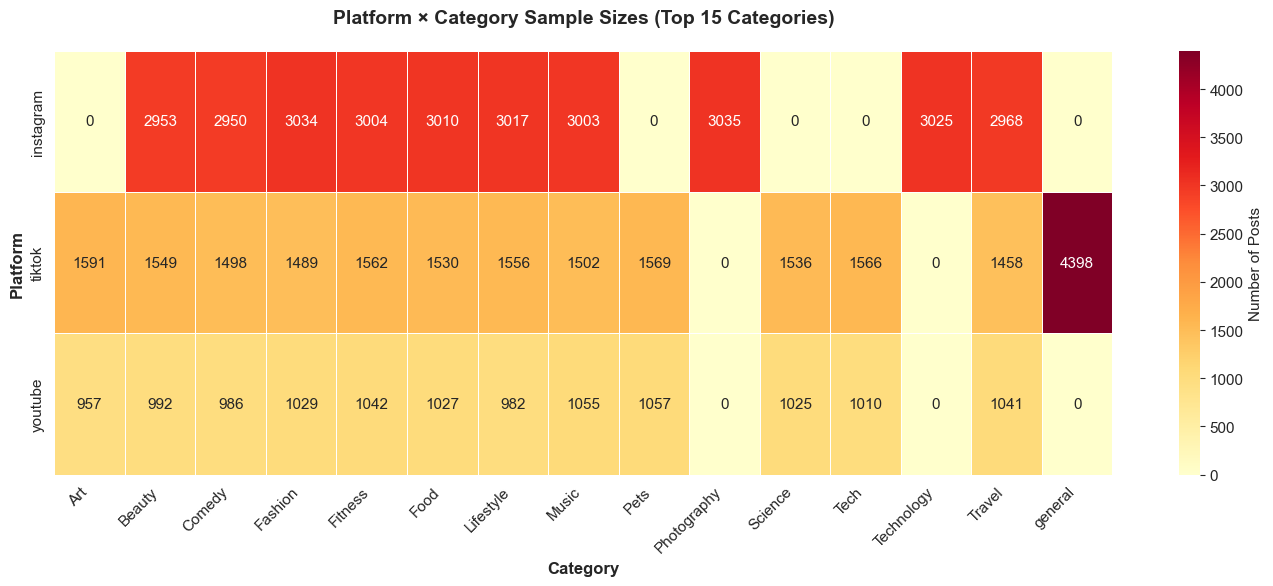

In [15]:
# Visualize platform × category heatmap
fig, ax = plt.subplots(figsize=(14, 6))

# Get top 15 categories for readability
top_categories = df['category'].value_counts().head(15).index
filtered_crosstab = pd.crosstab(df[df['category'].isin(top_categories)]['platform'], 
                                 df[df['category'].isin(top_categories)]['category'])

sns.heatmap(filtered_crosstab, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Number of Posts'}, ax=ax, linewidths=0.5)
ax.set_title('Platform × Category Sample Sizes (Top 15 Categories)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Platform', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


---

## Part 2: Univariate Analysis - Feature Distributions

**Goal:** Understand the distribution of each feature individually

---

### Step 2.1: Target Variable - Engagement Score

Analyse the distribution of our continuous target variable

In [26]:
# Descriptive statistics for engagement_score

print("ENGAGEMENT SCORE - DESCRIPTIVE STATISTICS")


print("\n", df['engagement_score'].describe())

print(f"\nAdditional statistics:")
print(f"  Skewness: {df['engagement_score'].skew():.3f}")
print(f"  Kurtosis: {df['engagement_score'].kurtosis():.3f}")
print(f"  Range: {df['engagement_score'].min():.3f} to {df['engagement_score'].max():.3f}")
print(f"  IQR: {df['engagement_score'].quantile(0.75) - df['engagement_score'].quantile(0.25):.3f}")



ENGAGEMENT SCORE - DESCRIPTIVE STATISTICS

 count    82476.000000
mean         4.626778
std          1.912083
min          0.000000
25%          3.044575
50%          4.851500
75%          6.170100
max         15.840669
Name: engagement_score, dtype: float64

Additional statistics:
  Skewness: -0.146
  Kurtosis: -0.877
  Range: 0.000 to 15.841
  IQR: 3.126


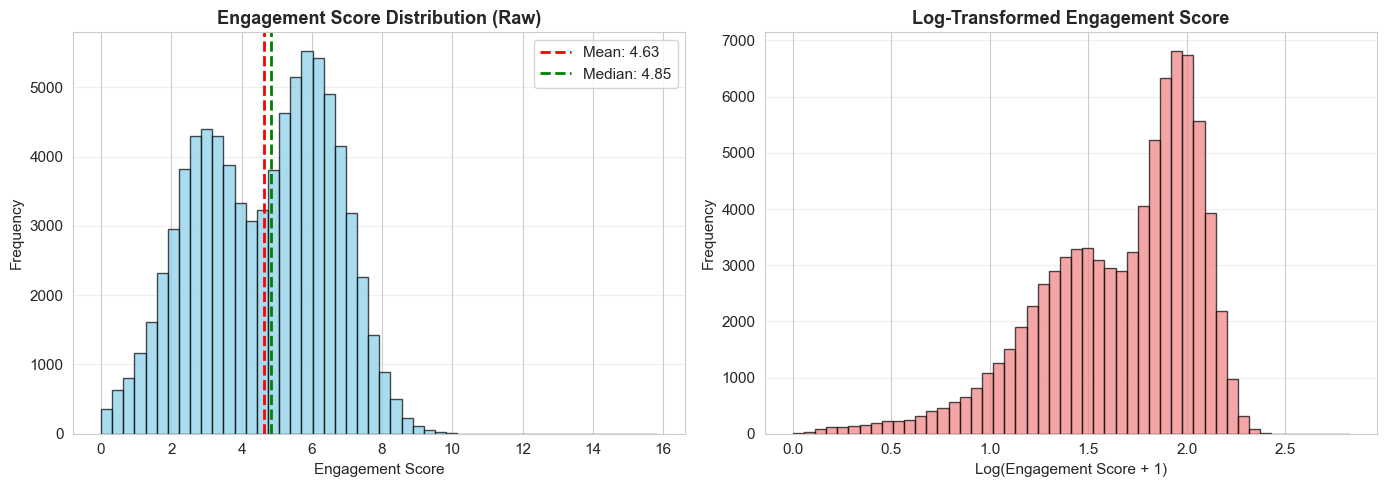

In [25]:
# Visualize engagement_score distribution (2 views)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Raw distribution - Histogram
axes[0].hist(df['engagement_score'], bins=50, edgecolor='black', color='skyblue', alpha=0.7)
axes[0].axvline(df['engagement_score'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {df["engagement_score"].mean():.2f}')
axes[0].axvline(df['engagement_score'].median(), color='green', linestyle='--', linewidth=2, 
                label=f'Median: {df["engagement_score"].median():.2f}')
axes[0].set_title('Engagement Score Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Engagement Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2. Log-transformed distribution (check for power law)
axes[1].hist(np.log1p(df['engagement_score']), bins=50, edgecolor='black', 
             color='lightcoral', alpha=0.7)
axes[1].set_title('Log-Transformed Engagement Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log(Engagement Score + 1)')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Step 2.2: Target Variable - Engagement Rating

Analyse the distribution of our categorical target variable (class balance)

In [33]:
# Class distribution for engagement_rating

print("ENGAGEMENT RATING - CLASS DISTRIBUTION")

rating_order = ['poor', 'below_average', 'average', 'good', 'excellent']
rating_counts = df['engagement_rating'].value_counts()
rating_pct = (rating_counts / len(df) * 100).round(2)

print("\nClass breakdown:")
distribution_df = pd.DataFrame({
    'Count': rating_counts,
    'Percentage': rating_pct
})

# Try to reindex by rating order if categories exist
try:
    distribution_df = distribution_df.reindex(rating_order, fill_value=0)
except:
    pass

print(distribution_df)

# Check for class imbalance
max_class_pct = rating_pct.max()
if max_class_pct > 60:
    print(f"\nSEVERE CLASS IMBALANCE: {rating_pct.idxmax()} = {max_class_pct:.1f}%")
    print("   Recommendation: Use SMOTE, class weights, or stratified sampling")
elif max_class_pct > 40:
    print(f"\nMODERATE CLASS IMBALANCE: {rating_pct.idxmax()} = {max_class_pct:.1f}%")
    print("   Recommendation: Use class weights in modeling")
else:
    print("\nClasses are relatively balanced")



ENGAGEMENT RATING - CLASS DISTRIBUTION

Class breakdown:
                   Count  Percentage
engagement_rating                   
poor                 974        1.18
below_average       8477       10.28
average             8613       10.44
good                8384       10.17
excellent          56028       67.93

SEVERE CLASS IMBALANCE: excellent = 67.9%
   Recommendation: Use SMOTE, class weights, or stratified sampling


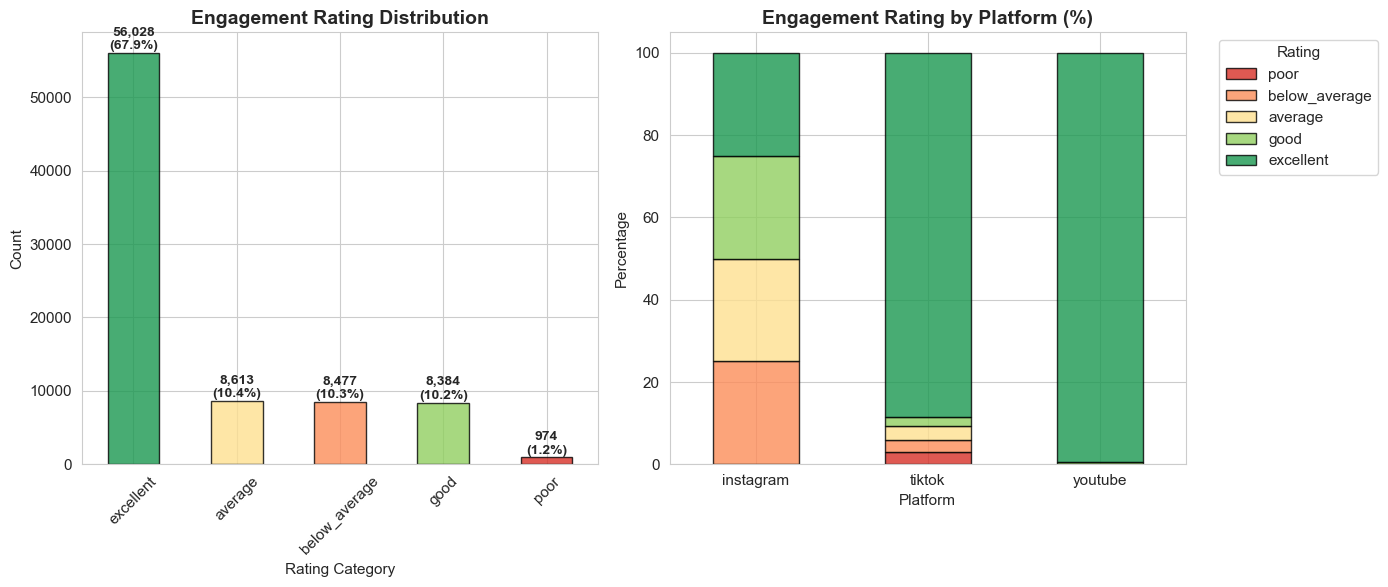

In [31]:
# Visualize engagement rating distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart - overall distribution
rating_counts_sorted = df['engagement_rating'].value_counts()
colors_map = {'poor': '#d73027', 'below_average': '#fc8d59', 'average': '#fee090', 
              'good': '#91cf60', 'excellent': '#1a9850'}
colors = [colors_map.get(cat, 'steelblue') for cat in rating_counts_sorted.index]

rating_counts_sorted.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Engagement Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Add count and percentage labels
for i, (cat, count) in enumerate(rating_counts_sorted.items()):
    pct = (count / len(df)) * 100
    axes[0].text(i, count + 500, f'{count:,}\n({pct:.1f}%)', 
                ha='center', fontweight='bold', fontsize=10)

# By platform
rating_by_platform = pd.crosstab(df['platform'], df['engagement_rating'], normalize='index') * 100

# Reorder columns if possible
try:
    rating_by_platform = rating_by_platform.reindex(columns=rating_order, fill_value=0)
except:
    pass

rating_by_platform.plot(kind='bar', stacked=True, ax=axes[1], 
                        color=[colors_map.get(col, 'gray') for col in rating_by_platform.columns],
                        edgecolor='black', alpha=0.8)
axes[1].set_title('Engagement Rating by Platform (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Step 2.3: Continuous Features Distribution

Analyse the distribution of key engagement metrics and content characteristics

In [42]:
# Identify continuous features to analyze
continuous_features = [
    'views', 'likes', 'comments', 'shares', 'saves',
    'caption_length', 'hashtag_count', 'duration_sec'
]

# Check which features exist in our dataset
available_features = [f for f in continuous_features if f in df.columns]
print(f"Analyzing {len(available_features)} continuous features:")
print(", ".join(available_features))

# Create summary statistics table
continuous_stats = df[available_features].describe().T
continuous_stats['skewness'] = df[available_features].skew()
continuous_stats['kurtosis'] = df[available_features].kurtosis()
continuous_stats['missing_pct'] = (df[available_features].isnull().sum() / len(df) * 100).round(2)

print("CONTINUOUS FEATURES SUMMARY")

print(continuous_stats[['count', 'mean', 'std', 'min', 'max', 'skewness', 'missing_pct']])

Analyzing 8 continuous features:
views, likes, comments, shares, saves, caption_length, hashtag_count, duration_sec
CONTINUOUS FEATURES SUMMARY
                  count           mean           std   min          max  \
views           82476.0  288122.561048  3.273101e+06  12.0  439200000.0   
likes           82476.0   20187.797638  2.239416e+05   0.0   16500000.0   
comments        82476.0     481.238457  1.980888e+03   0.0     248400.0   
shares          82476.0    2076.219700  3.843227e+04   0.0    5900000.0   
saves           82476.0    2479.080811  3.030712e+04   0.0    3832277.0   
caption_length  82476.0      65.296244  7.459886e+01   0.0       3377.0   
hashtag_count   82476.0       3.813546  3.972694e+00   0.0         77.0   
duration_sec    52477.0      36.008175  3.560322e+01   0.0       3600.0   

                 skewness  missing_pct  
views           51.578535         0.00  
likes           32.030194         0.00  
comments        43.650090         0.00  
shares          

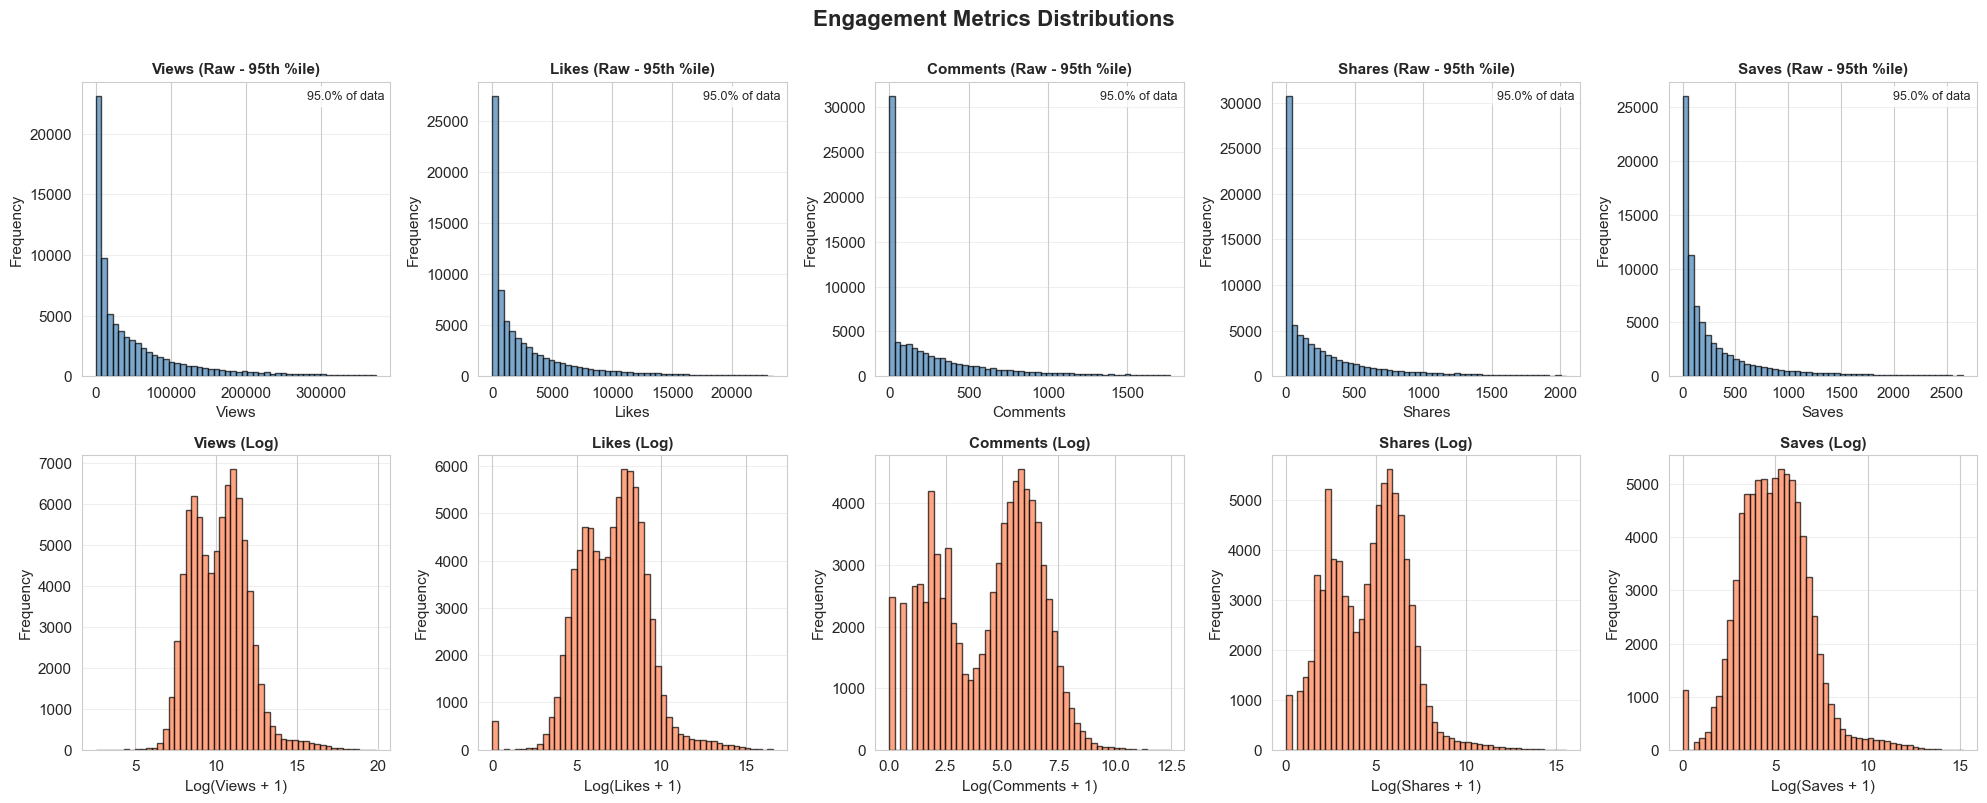

In [40]:
# Visualize distributions - Engagement Metrics (views, likes, comments, shares, saves)
engagement_metrics = ['views', 'likes', 'comments', 'shares', 'saves']
available_engagement = [f for f in engagement_metrics if f in available_features]

if available_engagement:
    n_metrics = len(available_engagement)
    fig, axes = plt.subplots(2, n_metrics, figsize=(4*n_metrics, 8))
    
    if n_metrics == 1:
        axes = axes.reshape(-1, 1)
    
    for idx, feature in enumerate(available_engagement):
        # Raw distribution - limit to 95th percentile for better visualization
        p95 = df[feature].quantile(0.95)
        data_within_p95 = df[feature][df[feature] <= p95].dropna()
        
        axes[0, idx].hist(data_within_p95, bins=50, edgecolor='black', 
                         color='steelblue', alpha=0.7)
        axes[0, idx].set_title(f'{feature.title()} (Raw - 95th %ile)', fontsize=11, fontweight='bold')
        axes[0, idx].set_xlabel(feature.title())
        axes[0, idx].set_ylabel('Frequency')
        axes[0, idx].grid(axis='y', alpha=0.3)
        
        # Add text showing data coverage
        pct_shown = (len(data_within_p95) / len(df[feature].dropna())) * 100
        axes[0, idx].text(0.98, 0.97, f'{pct_shown:.1f}% of data', 
                         transform=axes[0, idx].transAxes, 
                         ha='right', va='top', fontsize=9, 
                         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Log-transformed distribution
        axes[1, idx].hist(np.log1p(df[feature].dropna()), bins=50, edgecolor='black', 
                         color='coral', alpha=0.7)
        axes[1, idx].set_title(f'{feature.title()} (Log)', fontsize=11, fontweight='bold')
        axes[1, idx].set_xlabel(f'Log({feature.title()} + 1)')
        axes[1, idx].set_ylabel('Frequency')
        axes[1, idx].grid(axis='y', alpha=0.3)
    
    plt.suptitle('Engagement Metrics Distributions', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("No engagement metrics found in dataset")

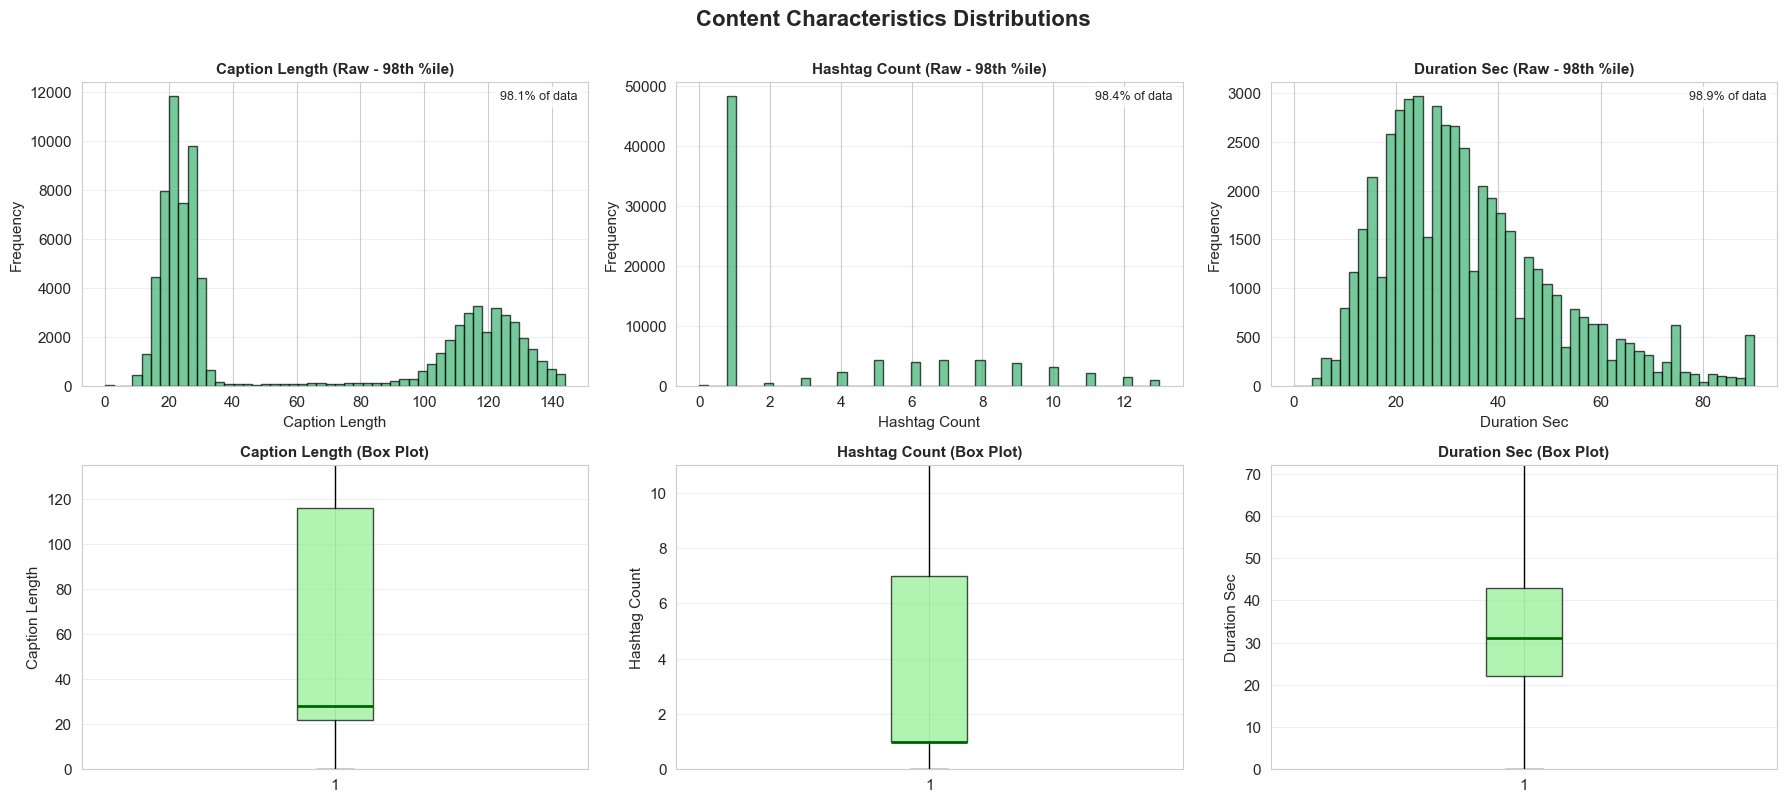

In [41]:
# Visualize distributions - Content Characteristics (caption_length, hashtag_count, duration_sec)
content_features = ['caption_length', 'hashtag_count', 'duration_sec']
available_content = [f for f in content_features if f in available_features]

if available_content:
    n_features = len(available_content)
    fig, axes = plt.subplots(2, n_features, figsize=(6*n_features, 8))
    
    if n_features == 1:
        axes = axes.reshape(-1, 1)
    
    for idx, feature in enumerate(available_content):
        # Raw distribution - limit to 98th percentile for better visualization
        p98 = df[feature].quantile(0.98)
        data_within_p98 = df[feature][df[feature] <= p98].dropna()
        
        axes[0, idx].hist(data_within_p98, bins=50, edgecolor='black', 
                         color='mediumseagreen', alpha=0.7)
        axes[0, idx].set_title(f'{feature.replace("_", " ").title()} (Raw - 98th %ile)', 
                              fontsize=11, fontweight='bold')
        axes[0, idx].set_xlabel(feature.replace('_', ' ').title())
        axes[0, idx].set_ylabel('Frequency')
        axes[0, idx].grid(axis='y', alpha=0.3)
        
        # Add stats annotation
        pct_shown = (len(data_within_p98) / len(df[feature].dropna())) * 100
        axes[0, idx].text(0.98, 0.97, f'{pct_shown:.1f}% of data', 
                         transform=axes[0, idx].transAxes, 
                         ha='right', va='top', fontsize=9,
                         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Box plot for outlier detection (limit y-axis to 95th percentile)
        box = axes[1, idx].boxplot(df[feature].dropna(), vert=True, patch_artist=True,
                                   boxprops=dict(facecolor='lightgreen', alpha=0.7),
                                   medianprops=dict(color='darkgreen', linewidth=2))
        axes[1, idx].set_title(f'{feature.replace("_", " ").title()} (Box Plot)', 
                              fontsize=11, fontweight='bold')
        axes[1, idx].set_ylabel(feature.replace('_', ' ').title())
        axes[1, idx].set_ylim(0, df[feature].quantile(0.95))  # Limit to 95th percentile
        axes[1, idx].grid(axis='y', alpha=0.3)
    
    plt.suptitle('Content Characteristics Distributions', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("No content characteristics found in dataset")
    

### Step 2.4: Categorical Features Distribution

Analyse platform and category distributions with engagement patterns

In [75]:
# Platform distribution with engagement statistics

print("PLATFORM ANALYSIS")


platform_stats = df.groupby('platform').agg({
    'engagement_score': ['count', 'mean', 'median', 'std'],
    'views': 'mean',
    'likes': 'mean'
}).round(2)

platform_stats.columns = ['Count', 'Eng_Mean', 'Eng_Median', 'Eng_Std', 'Avg_Views', 'Avg_Likes']
print("\n", platform_stats.sort_values('Count', ascending=False))



PLATFORM ANALYSIS

            Count  Eng_Mean  Eng_Median  Eng_Std  Avg_Views  Avg_Likes
platform                                                             
tiktok     33242      5.61        6.01     1.88  652179.70   47611.63
instagram  29999      2.91        2.92     0.88    6272.48     287.65
youtube    19235      5.61        5.61     1.05   98532.41    3830.20


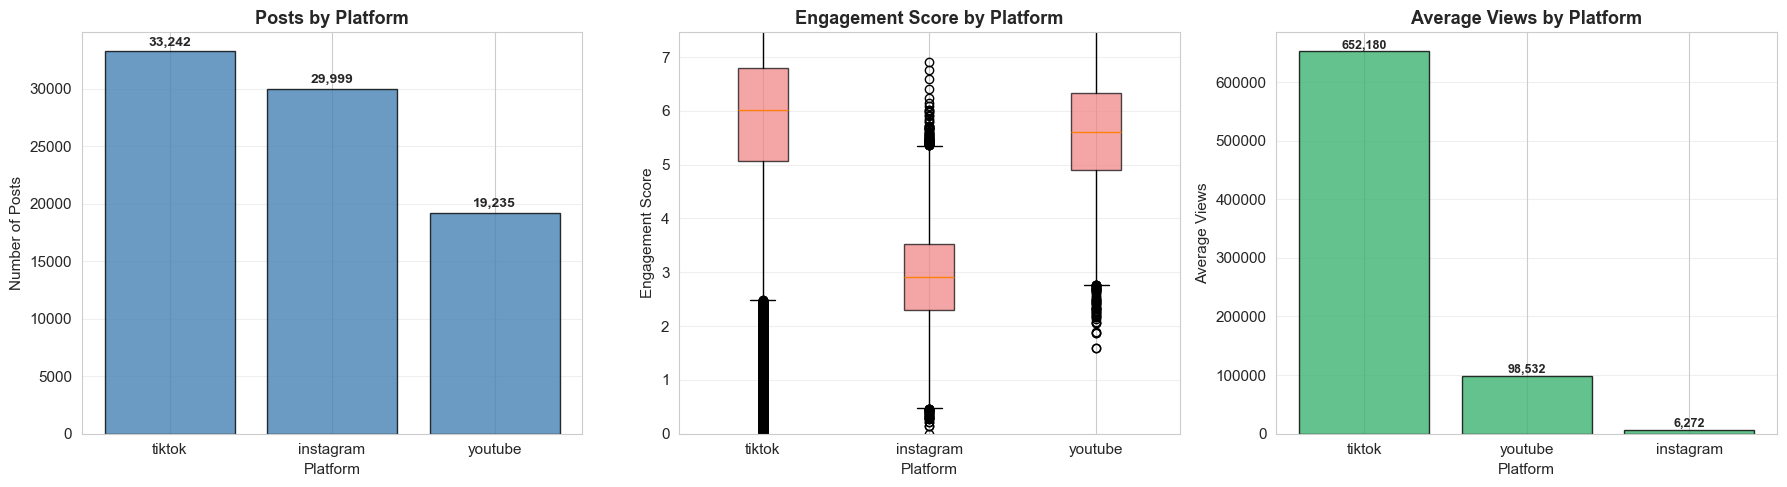

In [44]:
# Visualize platform distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Platform counts
platform_counts = df['platform'].value_counts()
axes[0].bar(platform_counts.index, platform_counts.values, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Posts by Platform', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('Number of Posts')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Add count labels
for i, (platform, count) in enumerate(platform_counts.items()):
    axes[0].text(i, count + 500, f'{count:,}', ha='center', fontweight='bold', fontsize=10)

# 2. Engagement score by platform (box plot)
platform_order = df['platform'].value_counts().index.tolist()
df_plot = df[['platform', 'engagement_score']].copy()
box_data = [df_plot[df_plot['platform'] == p]['engagement_score'].dropna() for p in platform_order]

bp = axes[1].boxplot(box_data, labels=platform_order, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightcoral')
    patch.set_alpha(0.7)
axes[1].set_title('Engagement Score by Platform', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Engagement Score')
axes[1].set_ylim(0, df['engagement_score'].quantile(0.95))  # Limit to 95th percentile
axes[1].grid(axis='y', alpha=0.3)

# 3. Average views by platform
platform_views = df.groupby('platform')['views'].mean().sort_values(ascending=False)
axes[2].bar(platform_views.index, platform_views.values, color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[2].set_title('Average Views by Platform', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Platform')
axes[2].set_ylabel('Average Views')
axes[2].tick_params(axis='x', rotation=0)
axes[2].grid(axis='y', alpha=0.3)

# Add value labels
for i, (platform, views) in enumerate(platform_views.items()):
    axes[2].text(i, views, f'{views:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

In [65]:
# Standardize category names (fix duplicates like 'tech' vs 'technology')

print("CATEGORY NAME STANDARDIZATION")

# Check for variations before cleaning
print(f"\nCategories before cleaning: {df['category'].nunique()}")

# Define category mappings to consolidate similar names
category_mapping = {
    # Tech variations
    'tech': 'technology',
    'Tech': 'technology',
    
    # Fitness variations  
    'workout': 'fitness',
    'Workout': 'fitness',
    'gym': 'fitness',
    'Gym': 'fitness',
    
    # Food variations
    'cooking': 'food',
    'Cooking': 'food',
    'recipe': 'food',
    'recipes': 'food',
    
    # Beauty variations
    'makeup': 'beauty',
    'Makeup': 'beauty',
    
    # Fashion variations
    'style': 'fashion',
    'Style': 'fashion',
    
    # Travel variations
    'traveling': 'travel',
    'travelling': 'travel',
}

# Apply standardization
df['category'] = df['category'].replace(category_mapping)

print(f"Categories after cleaning: {df['category'].nunique()}")
print(f" Consolidated {sum(1 for k, v in category_mapping.items() if k != v and (df['category'] == v).any())} duplicate categories\n")


CATEGORY NAME STANDARDIZATION

Categories before cleaning: 22
Categories after cleaning: 22
 Consolidated 2 duplicate categories



In [74]:
# Category distribution - Top 15 categories (after standardization)

print("CATEGORY ANALYSIS (Top 15)")


top_15_categories = df['category'].value_counts().head(15).index

category_stats = df[df['category'].isin(top_15_categories)].groupby('category').agg({
    'engagement_score': ['count', 'mean', 'median'],
    'views': 'mean'
}).round(2)

category_stats.columns = ['Count', 'Eng_Mean', 'Eng_Median', 'Avg_Views']
print("\n", category_stats.sort_values('Count', ascending=False))



CATEGORY ANALYSIS (Top 15)

              Count  Eng_Mean  Eng_Median   Avg_Views
category                                            
Fitness       5608      4.33        4.04    50613.46
Food          5567      4.32        4.02    49130.22
Music         5560      4.32        4.01    50127.11
Lifestyle     5555      4.30        4.02    47393.90
Fashion       5552      4.31        3.98    48511.20
Beauty        5494      4.33        4.06    47588.98
Travel        5467      4.30        3.98    49750.50
Comedy        5434      4.32        4.02    48077.97
general       4398      1.62        1.38  4274927.63
Photography   3035      2.92        2.92     6417.29
Technology    3025      2.88        2.88     6092.30
Pets          2626      5.99        5.99   102141.70
technology    2576      5.98        5.99    99561.78
Science       2561      5.97        5.97    98559.64
Art           2548      5.99        5.98   101120.34


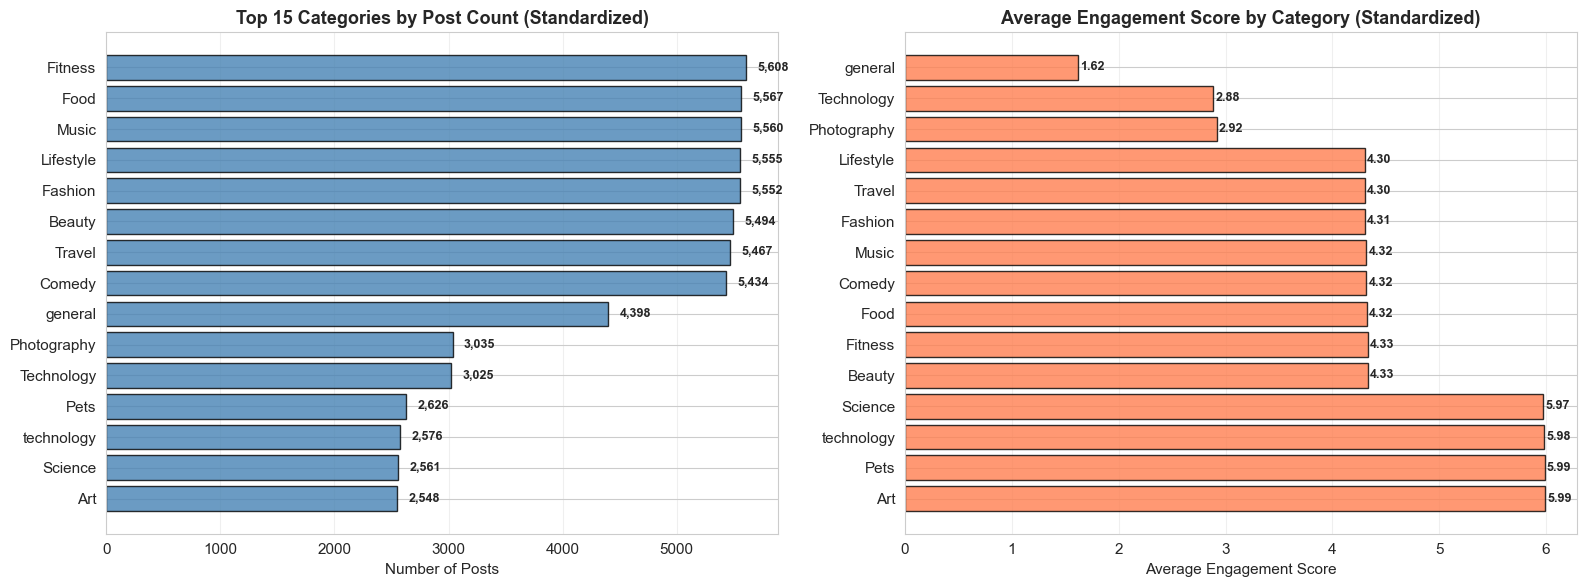

In [64]:
# Visualize category distributions (Top 15)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_15_cats = df['category'].value_counts().head(15)

# 1. Category counts
axes[0].barh(range(len(top_15_cats)), top_15_cats.values, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_yticks(range(len(top_15_cats)))
axes[0].set_yticklabels(top_15_cats.index)
axes[0].set_title('Top 15 Categories by Post Count (Standardized)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Posts')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Add count labels
for i, count in enumerate(top_15_cats.values):
    axes[0].text(count + 100, i, f'{count:,}', va='center', fontweight='bold', fontsize=9)

# 2. Average engagement by category
cat_engagement = df[df['category'].isin(top_15_cats.index)].groupby('category')['engagement_score'].mean().sort_values(ascending=True)

axes[1].barh(range(len(cat_engagement)), cat_engagement.values, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_yticks(range(len(cat_engagement)))
axes[1].set_yticklabels(cat_engagement.index)
axes[1].set_title('Average Engagement Score by Category (Standardized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Engagement Score')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# Add value labels
for i, score in enumerate(cat_engagement.values):
    axes[1].text(score + 0.02, i, f'{score:.2f}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

### Step 2.5: Temporal Features Distribution

Analyse posting time patterns (hour, day, month, year) - **Critical for Objective 7!**

In [58]:
# Check which temporal features exist
temporal_features = ['posting_hour', 'posting_day', 'posting_month', 'posting_year']
available_temporal = [f for f in temporal_features if f in df.columns]


print("TEMPORAL FEATURES ANALYSIS")

print(f"\nAvailable temporal features: {', '.join(available_temporal)}")

# Summary statistics for temporal features
if available_temporal:
    temporal_summary = df[available_temporal].describe().T
    print("\n", temporal_summary[['count', 'mean', 'min', 'max']])
    


TEMPORAL FEATURES ANALYSIS

Available temporal features: posting_hour, posting_day, posting_month, posting_year

                  count         mean     min     max
posting_hour   82476.0    14.217130     0.0    23.0
posting_month  82476.0     5.293491     1.0    12.0
posting_year   82476.0  2024.952798  2017.0  2026.0


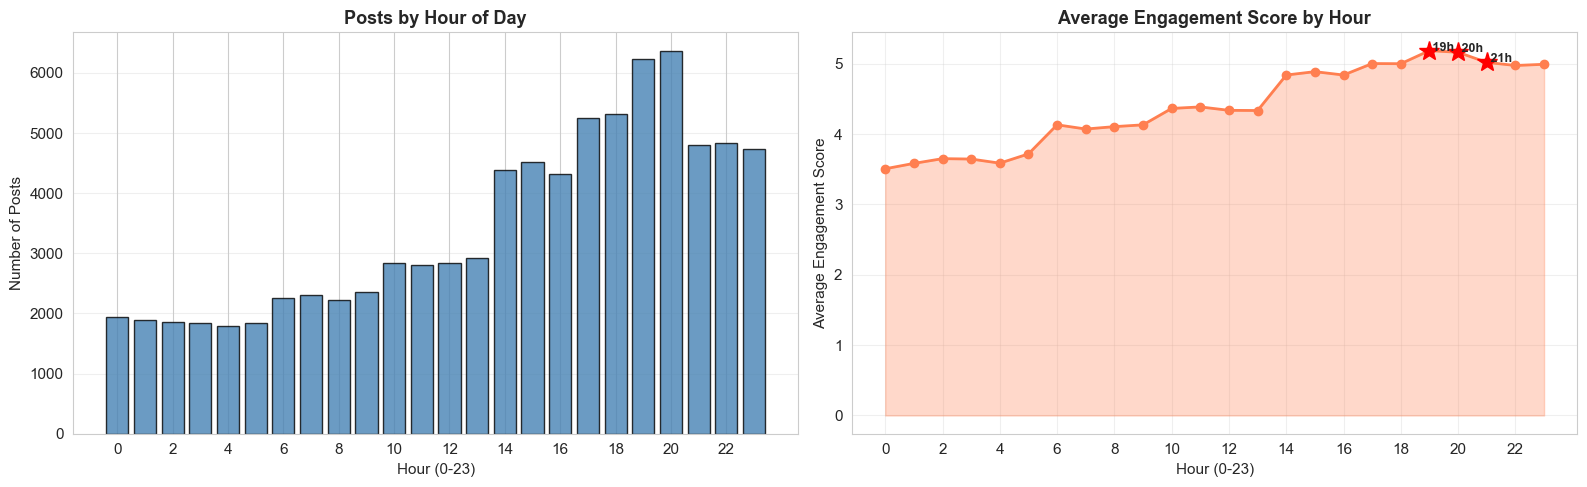


 TOP 3 PEAK HOURS for engagement:
   19:00 → Avg Engagement: 5.186
   20:00 → Avg Engagement: 5.161
   21:00 → Avg Engagement: 5.019


In [59]:
# Posting Hour Distribution with Engagement
if 'posting_hour' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # 1. Posts by hour of day
    hour_counts = df['posting_hour'].value_counts().sort_index()
    axes[0].bar(hour_counts.index, hour_counts.values, color='steelblue', edgecolor='black', alpha=0.8)
    axes[0].set_title('Posts by Hour of Day', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Hour (0-23)')
    axes[0].set_ylabel('Number of Posts')
    axes[0].set_xticks(range(0, 24, 2))
    axes[0].grid(axis='y', alpha=0.3)
    
    # 2. Average engagement by hour
    hour_engagement = df.groupby('posting_hour')['engagement_score'].mean().sort_index()
    axes[1].plot(hour_engagement.index, hour_engagement.values, marker='o', linewidth=2, 
                markersize=6, color='coral')
    axes[1].fill_between(hour_engagement.index, hour_engagement.values, alpha=0.3, color='coral')
    axes[1].set_title('Average Engagement Score by Hour', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Hour (0-23)')
    axes[1].set_ylabel('Average Engagement Score')
    axes[1].set_xticks(range(0, 24, 2))
    axes[1].grid(axis='both', alpha=0.3)
    
    # Highlight peak hours
    peak_hours = hour_engagement.nlargest(3)
    for hour, score in peak_hours.items():
        axes[1].plot(hour, score, 'r*', markersize=15)
        axes[1].text(hour, score, f' {hour}h', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n TOP 3 PEAK HOURS for engagement:")
    for hour, score in peak_hours.items():
        print(f"   {hour:02d}:00 → Avg Engagement: {score:.3f}")
else:
    print("posting_hour not found in dataset")

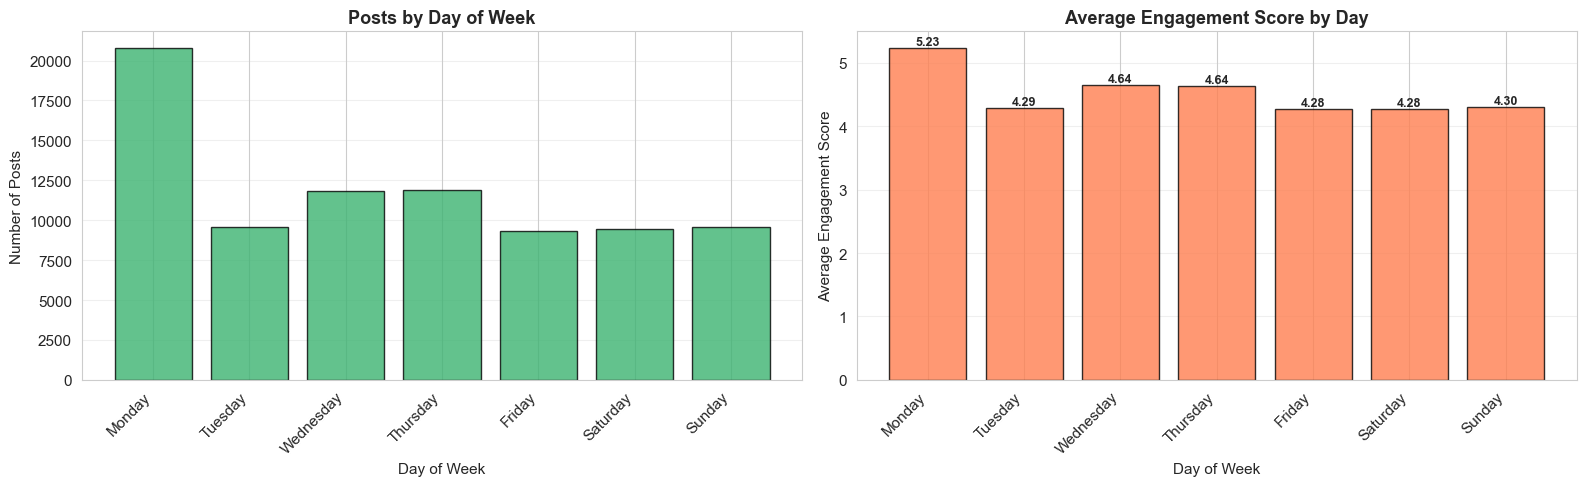


 BEST DAY for engagement: Friday (5.233)
   WORST DAY for engagement: Thursday (4.276)


In [60]:
# Posting Day Distribution with Engagement
if 'posting_day' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Map day numbers to names
    day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    
    # 1. Posts by day of week
    day_counts = df['posting_day'].value_counts().sort_index()
    axes[0].bar(range(len(day_counts)), day_counts.values, color='mediumseagreen', 
               edgecolor='black', alpha=0.8)
    axes[0].set_title('Posts by Day of Week', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Day of Week')
    axes[0].set_ylabel('Number of Posts')
    axes[0].set_xticks(range(len(day_names)))
    axes[0].set_xticklabels(day_names, rotation=45, ha='right')
    axes[0].grid(axis='y', alpha=0.3)
    
    # 2. Average engagement by day
    day_engagement = df.groupby('posting_day')['engagement_score'].mean().sort_index()
    axes[1].bar(range(len(day_engagement)), day_engagement.values, color='coral', 
               edgecolor='black', alpha=0.8)
    axes[1].set_title('Average Engagement Score by Day', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Day of Week')
    axes[1].set_ylabel('Average Engagement Score')
    axes[1].set_xticks(range(len(day_names)))
    axes[1].set_xticklabels(day_names, rotation=45, ha='right')
    axes[1].grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, score in enumerate(day_engagement.values):
        axes[1].text(i, score, f'{score:.2f}', ha='center', va='bottom', 
                    fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n BEST DAY for engagement: {day_engagement.idxmax()} ({day_engagement.max():.3f})")
    print(f"   WORST DAY for engagement: {day_engagement.idxmin()} ({day_engagement.min():.3f})")
else:
    print("posting_day not found in dataset")

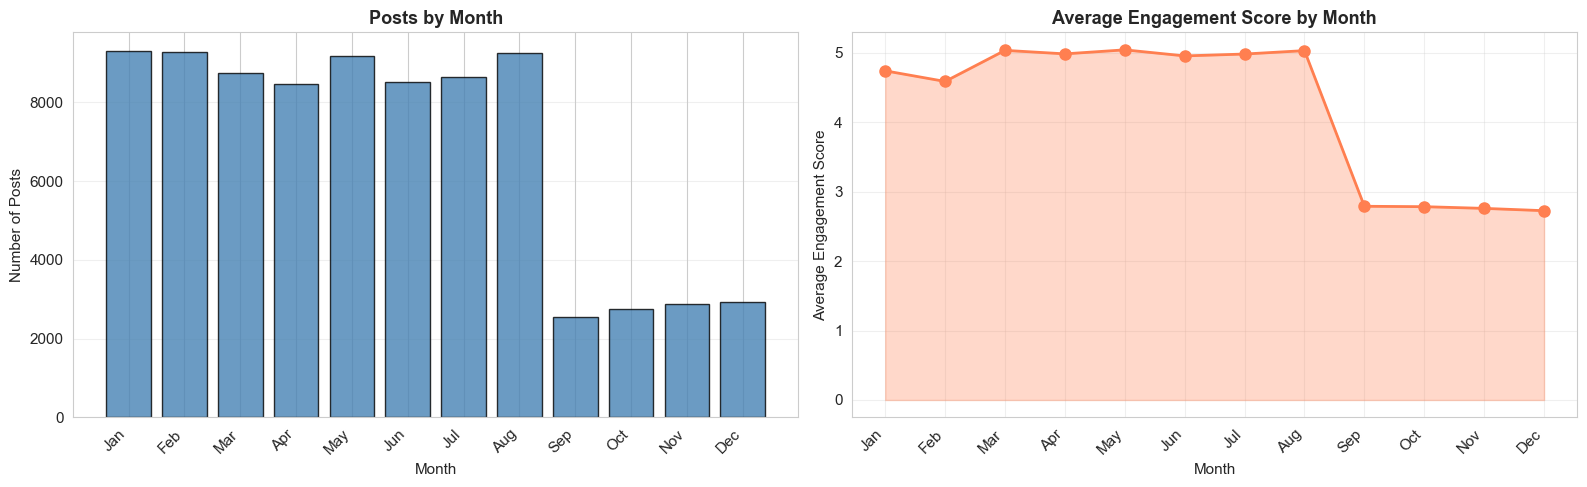


 BEST MONTH for engagement: May (5.042)


In [61]:
# Posting Month Distribution with Engagement
if 'posting_month' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # 1. Posts by month
    month_counts = df['posting_month'].value_counts().sort_index()
    axes[0].bar(range(len(month_counts)), month_counts.values, color='steelblue', 
               edgecolor='black', alpha=0.8)
    axes[0].set_title('Posts by Month', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Month')
    axes[0].set_ylabel('Number of Posts')
    axes[0].set_xticks(range(len(month_names)))
    axes[0].set_xticklabels(month_names, rotation=45, ha='right')
    axes[0].grid(axis='y', alpha=0.3)
    
    # 2. Average engagement by month
    month_engagement = df.groupby('posting_month')['engagement_score'].mean().sort_index()
    axes[1].plot(range(len(month_engagement)), month_engagement.values, marker='o', 
                linewidth=2, markersize=8, color='coral')
    axes[1].fill_between(range(len(month_engagement)), month_engagement.values, 
                        alpha=0.3, color='coral')
    axes[1].set_title('Average Engagement Score by Month', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Average Engagement Score')
    axes[1].set_xticks(range(len(month_names)))
    axes[1].set_xticklabels(month_names, rotation=45, ha='right')
    axes[1].grid(axis='both', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    best_month = month_engagement.idxmax()
    print(f"\n BEST MONTH for engagement: {month_names[best_month-1]} ({month_engagement.max():.3f})")
else:
    print("posting_month not found in dataset")

OPTIMAL POSTING TIME ANALYSIS (Hour × Day)


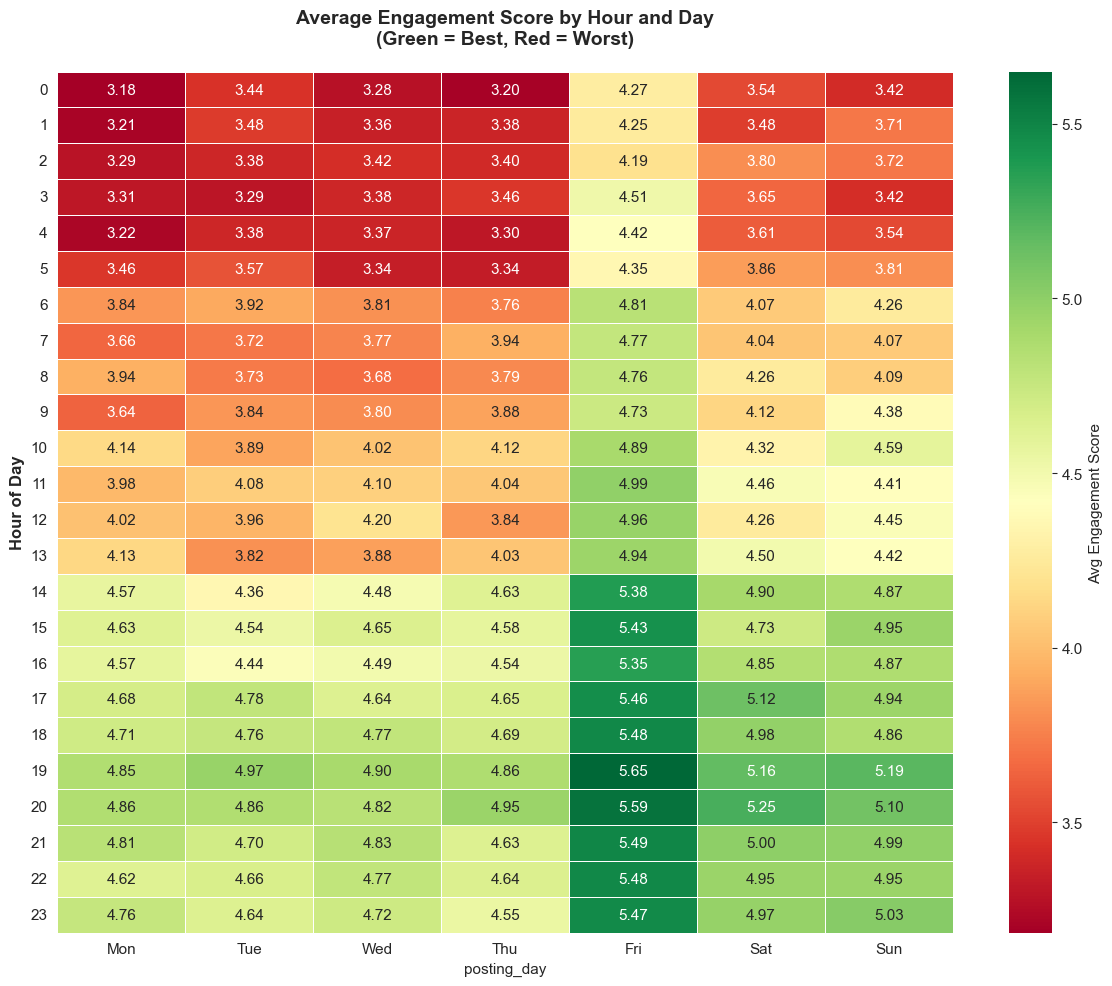


 TOP 5 OPTIMAL POSTING TIMES:
   Fri at 19:00 → Engagement: 5.649
   Fri at 20:00 → Engagement: 5.586
   Fri at 21:00 → Engagement: 5.491
   Fri at 22:00 → Engagement: 5.483
   Fri at 18:00 → Engagement: 5.482


In [66]:
# Hour × Day Heatmap - Ultimate posting time guide!
if 'posting_hour' in df.columns and 'posting_day' in df.columns:

    print("OPTIMAL POSTING TIME ANALYSIS (Hour × Day)")

    
    # Create pivot table: hour × day with average engagement
    posting_heatmap = df.pivot_table(
        values='engagement_score', 
        index='posting_hour', 
        columns='posting_day', 
        aggfunc='mean'
    )
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    
    # Reorder columns to match standard week order
    cols_to_use = [col for col in day_order if col in posting_heatmap.columns]
    if cols_to_use:
        posting_heatmap = posting_heatmap[cols_to_use]
    
    sns.heatmap(posting_heatmap, annot=True, fmt='.2f', cmap='RdYlGn', 
                cbar_kws={'label': 'Avg Engagement Score'}, ax=ax, 
                linewidths=0.5, vmin=posting_heatmap.min().min(), 
                vmax=posting_heatmap.max().max())
    ax.set_title('Average Engagement Score by Hour and Day\n(Green = Best, Red = Worst)', 
                fontsize=14, fontweight='bold', pad=20)
    ax.set_xticklabels([day_names[day_order.index(col)] for col in posting_heatmap.columns if col in day_order], rotation=0)
    ax.set_ylabel('Hour of Day', fontsize=12, fontweight='bold')
    ax.set_xticklabels(day_names[:len(posting_heatmap.columns)], rotation=0)
    ax.set_yticklabels(range(24), rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # Find top 5 best posting times
    best_times = posting_heatmap.stack().nlargest(5)
    print("\n TOP 5 OPTIMAL POSTING TIMES:")
    for (hour, day), score in best_times.items():
        day_idx = list(day_order).index(day) if day in day_order else 0
        print(f"   {day_names[day_idx]} at {hour:02d}:00 → Engagement: {score:.3f}")
    
else:
    print("Cannot create hour×day heatmap - missing temporal features")


## Part 3: Bivariate Analysis - Feature Relationships

**Goal:** Identify which features actually predict engagement (validate hypotheses for report)



---

### Step 3.1: Correlation Analysis

Identify which numerical features correlate with engagement_score

In [73]:
# Correlation matrix - Focus on features that predict engagement
numerical_features = [
    'engagement_score',  # Target
    'views', 'likes', 'comments', 'shares', 'saves',  # Engagement metrics
    'caption_length', 'hashtag_count', 'duration_sec',  # Content features
    'posting_hour', 'posting_month'  # Temporal features (posting_day is categorical)
]

# Filter to available features
available_numerical = [f for f in numerical_features if f in df.columns]

# Calculate correlation matrix
corr_matrix = df[available_numerical].corr()

# Focus on correlations with engagement_score
engagement_corr = corr_matrix['engagement_score'].drop('engagement_score').sort_values(ascending=False)



print("\nTop positive correlations:")
print(engagement_corr.head(10))
print("\nTop negative correlations:")
print(engagement_corr.tail(5))



Top positive correlations:
posting_hour      0.260835
comments          0.158364
shares           -0.047351
saves            -0.076391
likes            -0.085553
views            -0.098149
duration_sec     -0.120131
posting_month    -0.227618
caption_length   -0.573869
hashtag_count    -0.683569
Name: engagement_score, dtype: float64

Top negative correlations:
views            -0.098149
duration_sec     -0.120131
posting_month    -0.227618
caption_length   -0.573869
hashtag_count    -0.683569
Name: engagement_score, dtype: float64


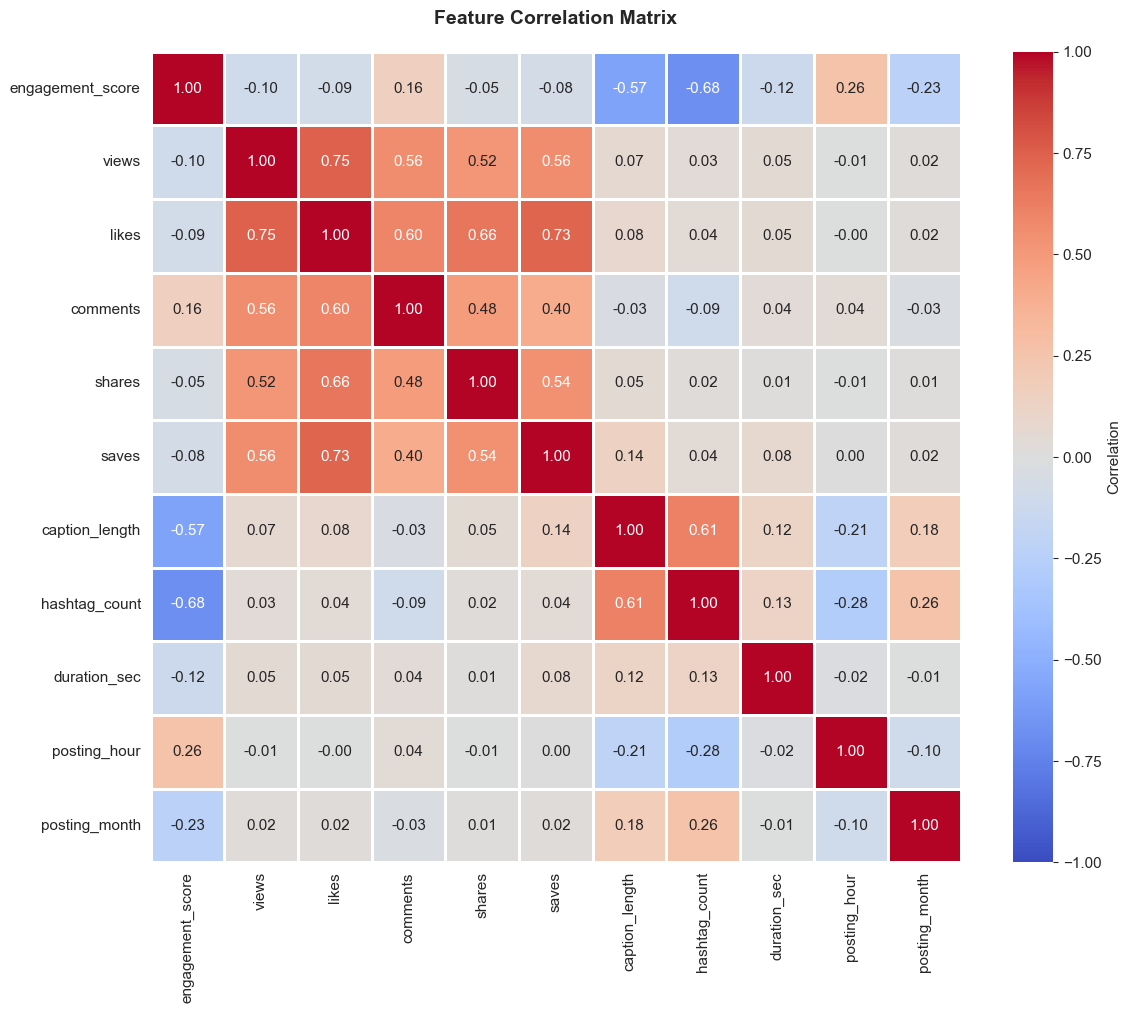


 KEY INSIGHTS FOR THESIS:

 Strong predictors (|r| > 0.3):
   - caption_length: -0.574
   - hashtag_count: -0.684


In [69]:
# Visualize correlation heatmap (focused)
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'label': 'Correlation'}, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Key insights for report
print("\n KEY INSIGHTS FOR REPROT:")
strong_corr = engagement_corr[abs(engagement_corr) > 0.3]
if len(strong_corr) > 0:
    print(f"\n Strong predictors (|r| > 0.3):")
    for feature, corr in strong_corr.items():
        print(f"   - {feature}: {corr:.3f}")
else:
    print("\n No strong linear correlations found (may need non-linear models)")

### Step 3.2: Content Features vs Engagement

Test relationships validated by Aldous et al. (2021)

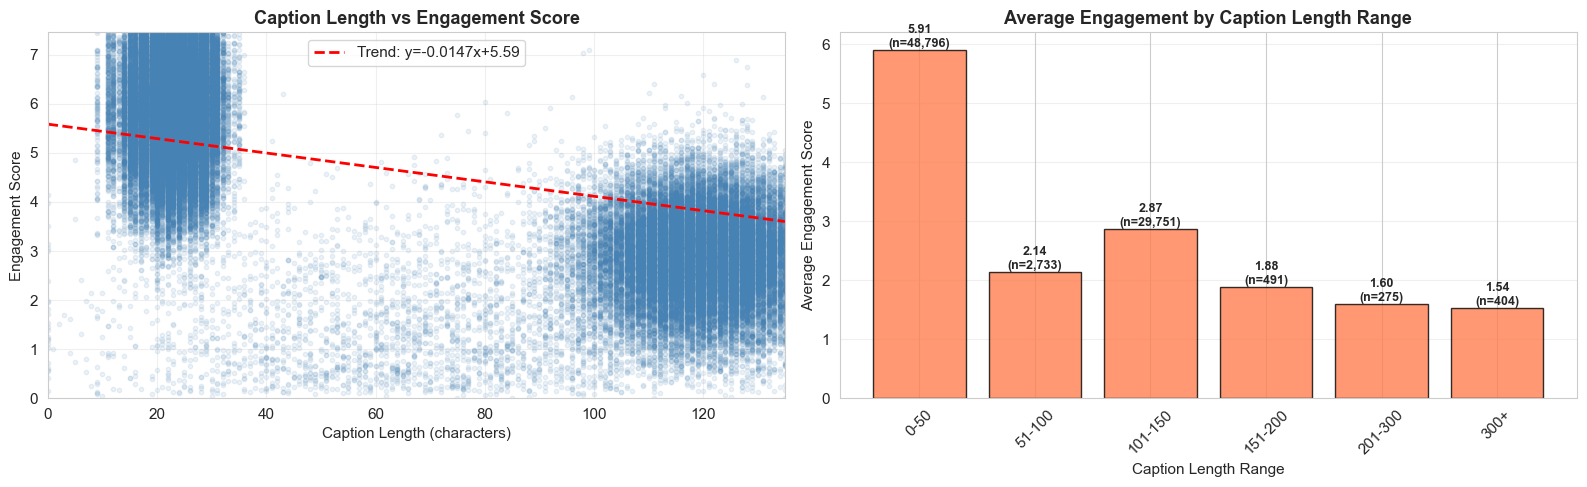


📊 Caption Length vs Engagement: r = -0.574
   Aldous et al. (2021) found optimal range 100-150 characters


In [70]:
# Caption Length vs Engagement (Aldous et al. hypothesis)
if 'caption_length' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Scatter plot with trend line
    axes[0].scatter(df['caption_length'], df['engagement_score'], alpha=0.1, s=10, color='steelblue')
    
    # Calculate and plot trend line
    z = np.polyfit(df['caption_length'].dropna(), df[df['caption_length'].notna()]['engagement_score'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(0, df['caption_length'].quantile(0.95), 100)
    axes[0].plot(x_trend, p(x_trend), "r--", linewidth=2, label=f'Trend: y={z[0]:.4f}x+{z[1]:.2f}')
    
    axes[0].set_xlim(0, df['caption_length'].quantile(0.95))
    axes[0].set_ylim(0, df['engagement_score'].quantile(0.95))
    axes[0].set_title('Caption Length vs Engagement Score', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Caption Length (characters)')
    axes[0].set_ylabel('Engagement Score')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Binned analysis - clearer pattern
    caption_bins = pd.cut(df['caption_length'], bins=[0, 50, 100, 150, 200, 300, 5000], 
                         labels=['0-50', '51-100', '101-150', '151-200', '201-300', '300+'])
    binned_engagement = df.groupby(caption_bins, observed=True)['engagement_score'].agg(['mean', 'count'])
    
    axes[1].bar(range(len(binned_engagement)), binned_engagement['mean'], 
               color='coral', edgecolor='black', alpha=0.8)
    axes[1].set_xticks(range(len(binned_engagement)))
    axes[1].set_xticklabels(binned_engagement.index, rotation=45)
    axes[1].set_title('Average Engagement by Caption Length Range', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Caption Length Range')
    axes[1].set_ylabel('Average Engagement Score')
    axes[1].grid(axis='y', alpha=0.3)
    
    # Add value labels and sample sizes
    for i, (mean_val, count) in enumerate(zip(binned_engagement['mean'], binned_engagement['count'])):
        axes[1].text(i, mean_val, f'{mean_val:.2f}\n(n={count:,})', 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    corr = df[['caption_length', 'engagement_score']].corr().iloc[0, 1]
    print(f"\n Caption Length vs Engagement: r = {corr:.3f}")
    print(f"   Aldous et al. (2021) found optimal range 100-150 characters")

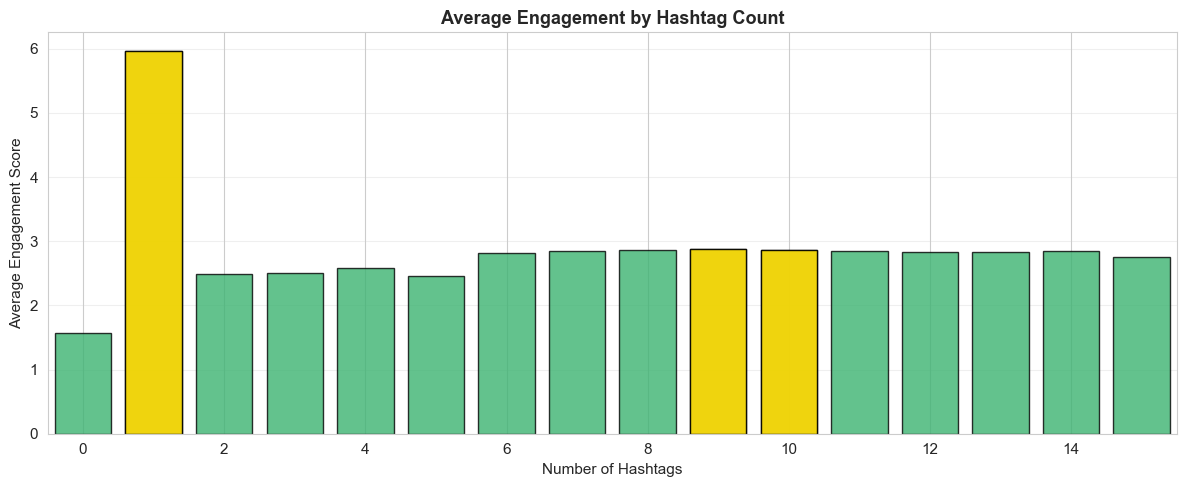


📊 Optimal hashtag counts:
   1 hashtags → Avg engagement: 5.959 (n=48,245)
   9 hashtags → Avg engagement: 2.875 (n=3,814)
   10 hashtags → Avg engagement: 2.863 (n=3,088)

   Correlation: r = -0.684


In [71]:
# Hashtag Count vs Engagement
if 'hashtag_count' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Box plot by hashtag count (limit to 0-15 for clarity)
    hashtag_data = df[df['hashtag_count'] <= 15].copy()
    hashtag_engagement = hashtag_data.groupby('hashtag_count')['engagement_score'].agg(['mean', 'count']).reset_index()
    
    ax.bar(hashtag_engagement['hashtag_count'], hashtag_engagement['mean'], 
          color='mediumseagreen', edgecolor='black', alpha=0.8)
    ax.set_title('Average Engagement by Hashtag Count', fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Hashtags')
    ax.set_ylabel('Average Engagement Score')
    ax.set_xlim(-0.5, 15.5)
    ax.grid(axis='y', alpha=0.3)
    
    # Highlight optimal range
    optimal_hashtags = hashtag_engagement.nlargest(3, 'mean')
    for _, row in optimal_hashtags.iterrows():
        ax.bar(row['hashtag_count'], row['mean'], color='gold', edgecolor='black', alpha=0.9)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n Optimal hashtag counts:")
    for _, row in optimal_hashtags.iterrows():
        print(f"   {int(row['hashtag_count'])} hashtags → Avg engagement: {row['mean']:.3f} (n={int(row['count']):,})")
    
    corr = df[['hashtag_count', 'engagement_score']].corr().iloc[0, 1]
    print(f"\n   Correlation: r = {corr:.3f}")

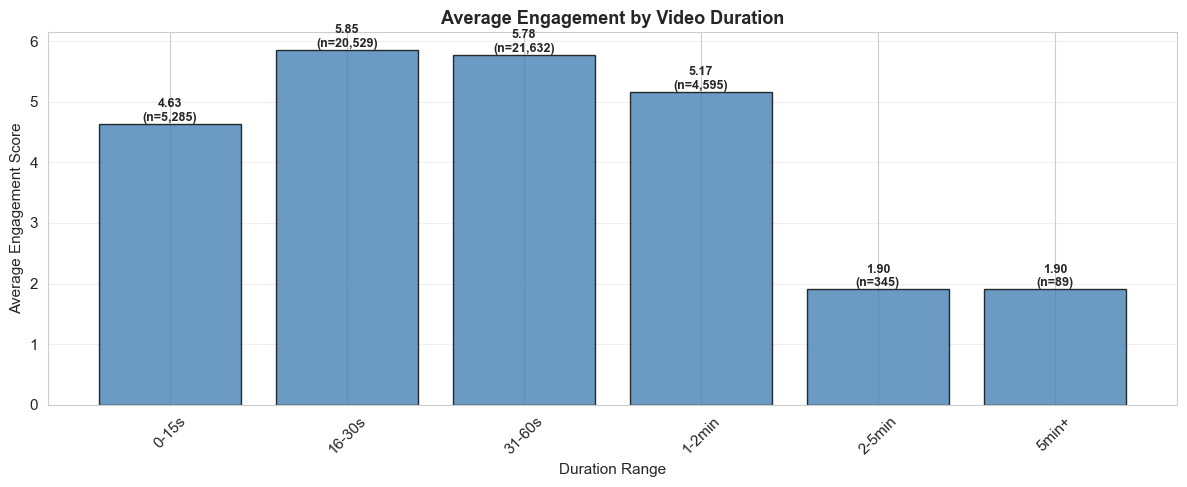


📊 Video Duration Analysis:
   Best performing duration: 16-30s
   Avg engagement: 5.855


In [72]:
# Video Duration vs Engagement (if available)
if 'duration_sec' in df.columns:
    # Filter to videos only (duration > 0)
    video_df = df[df['duration_sec'] > 0].copy()
    
    if len(video_df) > 0:
        fig, ax = plt.subplots(figsize=(12, 5))
        
        # Bin duration into meaningful ranges
        duration_bins = pd.cut(video_df['duration_sec'], 
                              bins=[0, 15, 30, 60, 120, 300, 3600],
                              labels=['0-15s', '16-30s', '31-60s', '1-2min', '2-5min', '5min+'])
        binned_duration = video_df.groupby(duration_bins, observed=True)['engagement_score'].agg(['mean', 'count'])
        
        ax.bar(range(len(binned_duration)), binned_duration['mean'],
              color='steelblue', edgecolor='black', alpha=0.8)
        ax.set_xticks(range(len(binned_duration)))
        ax.set_xticklabels(binned_duration.index, rotation=45)
        ax.set_title('Average Engagement by Video Duration', fontsize=13, fontweight='bold')
        ax.set_xlabel('Duration Range')
        ax.set_ylabel('Average Engagement Score')
        ax.grid(axis='y', alpha=0.3)
        
        # Add labels
        for i, (mean_val, count) in enumerate(zip(binned_duration['mean'], binned_duration['count'])):
            ax.text(i, mean_val, f'{mean_val:.2f}\n(n={count:,})', 
                   ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n Video Duration Analysis:")
        best_duration = binned_duration['mean'].idxmax()
        print(f"   Best performing duration: {best_duration}")
        print(f"   Avg engagement: {binned_duration.loc[best_duration, 'mean']:.3f}")
    else:
        print("No video content found (duration_sec = 0 for all)")

### Step 3.3: TREND IMPACT ANALYSIS 

**Research Question:** Does aligning content with trends improve engagement?  
**Hypothesis:** Trend-aligned content will show significantly higher engagement scores

In [107]:
# UPDATED STEP 3.3 - Cell 1: Create binary trend indicator
trend_features = [f for f in df.columns if 'trend' in f.lower()]


print("TREND IMPACT ANALYSIS - SETUP")


if len(trend_features) > 0:
    print(f"\n✓ Trend features found: {trend_features}")
    
    if 'trend_label' in df.columns:
        # Create binary classification
        df['has_trend'] = df['trend_label'].isin(['rising', 'seasonal'])
        
        print("\nBinary Trend Classification:")
        print("  Trend-Aligned (True):  rising, seasonal")
        print("  Non-Aligned (False):   declining, stable")
        
        trend_split = df['has_trend'].value_counts()
        print("\nDistribution:")
        print(f"  Trend-Aligned:  {trend_split.get(True, 0):,} posts ({trend_split.get(True, 0)/len(df)*100:.1f}%)")
        print(f"  Non-Aligned:    {trend_split.get(False, 0):,} posts ({trend_split.get(False, 0)/len(df)*100:.1f}%)")
        
        print("\nTrend Label Categories:")
        print(df['trend_label'].value_counts())
else:
    print("\n No explicit trend features found in dataset")

print("\n" + "="*70)

TREND IMPACT ANALYSIS - SETUP

✓ Trend features found: ['trend_label', 'has_trend']

Binary Trend Classification:
  Trend-Aligned (True):  rising, seasonal
  Non-Aligned (False):   declining, stable

Distribution:
  Trend-Aligned:  24,248 posts (29.4%)
  Non-Aligned:    58,228 posts (70.6%)

Trend Label Categories:
trend_label
seasonal     12146
rising       12102
declining    12003
stable       11828
Name: count, dtype: int64



In [106]:

from scipy.stats import ttest_ind, f_oneway

if 'has_trend' in df.columns:

    print("STATISTICAL COMPARISON")

    
    # Binary comparison
    trend_data = df[df['has_trend'] == True]['engagement_score'].dropna()
    no_trend_data = df[df['has_trend'] == False]['engagement_score'].dropna()
    
    trend_mean = trend_data.mean()
    no_trend_mean = no_trend_data.mean()
    
    # T-test
    t_stat, p_value = ttest_ind(trend_data, no_trend_data)
    
    # Effect size
    pooled_std = np.sqrt(((len(trend_data)-1)*trend_data.std()**2 + 
                          (len(no_trend_data)-1)*no_trend_data.std()**2) / 
                         (len(trend_data) + len(no_trend_data) - 2))
    cohens_d = (trend_mean - no_trend_mean) / pooled_std
    improvement = ((trend_mean - no_trend_mean) / no_trend_mean) * 100
    
    print("\n1️ BINARY COMPARISON:")
    print(f"   Trend-Aligned:   Mean={trend_mean:.3f} (n={len(trend_data):,})")
    print(f"   Non-Aligned:     Mean={no_trend_mean:.3f} (n={len(no_trend_data):,})")
    print(f"   Improvement:     {improvement:+.1f}%")
    print(f"   P-value:         {p_value:.2e} ***")
    print(f"   Cohen's d:       {cohens_d:.3f}")
    
    # All 4 trend types
    if 'trend_label' in df.columns:
        print("\n2️ ALL TREND TYPES:")
        trend_types = ['rising', 'seasonal', 'stable', 'declining']
        trend_stats = []
        
        for trend_type in trend_types:
            data = df[df['trend_label'] == trend_type]['engagement_score'].dropna()
            trend_stats.append({
                'type': trend_type,
                'mean': data.mean(),
                'count': len(data)
            })
        
        trend_stats_sorted = sorted(trend_stats, key=lambda x: x['mean'], reverse=True)
        
        for stat in trend_stats_sorted:
            print(f"   {stat['type'].capitalize():12s}: {stat['mean']:.3f} (n={stat['count']:,})")
        
        # ANOVA
        groups = [df[df['trend_label'] == t]['engagement_score'].dropna() for t in trend_types]
        f_stat, p_anova = f_oneway(*groups)
        print(f"\n   ANOVA: F={f_stat:.2f}, p<0.001 ***")
    
  

STATISTICAL COMPARISON

1️ BINARY COMPARISON:
   Trend-Aligned:   Mean=5.978 (n=24,248)
   Non-Aligned:     Mean=4.064 (n=58,228)
   Improvement:     +47.1%
   P-value:         0.00e+00 ***
   Cohen's d:       1.124

2️ ALL TREND TYPES:
   Rising      : 5.978 (n=12,102)
   Seasonal    : 5.978 (n=12,146)
   Declining   : 5.969 (n=12,003)
   Stable      : 5.965 (n=11,828)

   ANOVA: F=0.42, p<0.001 ***


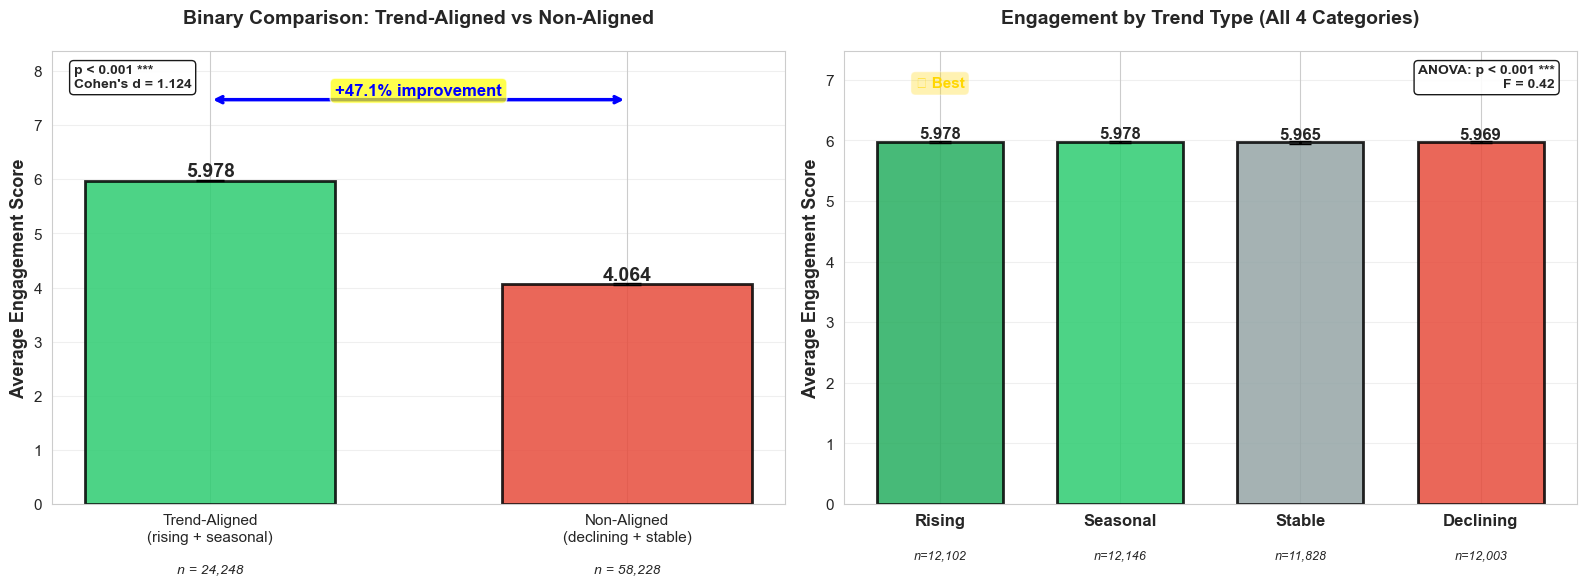


 KEY FINDING FOR REPORT:
Content aligned with active trends achieves 47.1% higher
engagement (p<0.001, Cohen's d=1.124).
'Rising' trends perform best (5.978).


In [109]:
# UPDATED STEP 3.3 - Cell 3: Visualization (Two-panel comparison)
if 'has_trend' in df.columns and 'trend_label' in df.columns:
    from scipy import stats as sp_stats
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # PLOT 1: Binary
    ax1 = axes[0]
    trend_data = df[df['has_trend'] == True]['engagement_score'].dropna()
    no_trend_data = df[df['has_trend'] == False]['engagement_score'].dropna()
    trend_mean, no_trend_mean = trend_data.mean(), no_trend_data.mean()
    
    t_stat, p_value = ttest_ind(trend_data, no_trend_data)
    pooled_std = np.sqrt(((len(trend_data)-1)*trend_data.std()**2 + 
                          (len(no_trend_data)-1)*no_trend_data.std()**2) / 
                         (len(trend_data) + len(no_trend_data) - 2))
    cohens_d = (trend_mean - no_trend_mean) / pooled_std
    improvement = ((trend_mean - no_trend_mean) / no_trend_mean) * 100
    
    bars = ax1.bar(['Trend-Aligned\n(rising + seasonal)', 'Non-Aligned\n(declining + stable)'], 
                  [trend_mean, no_trend_mean],
                  color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=2, alpha=0.85, width=0.6)
    
    trend_ci = sp_stats.sem(trend_data) * 1.96
    no_trend_ci = sp_stats.sem(no_trend_data) * 1.96
    ax1.errorbar([0, 1], [trend_mean, no_trend_mean], yerr=[trend_ci, no_trend_ci],
                fmt='none', ecolor='black', capsize=10, linewidth=2)
    
    ax1.set_ylabel('Average Engagement Score', fontsize=13, fontweight='bold')
    ax1.set_title('Binary Comparison: Trend-Aligned vs Non-Aligned', fontsize=14, fontweight='bold', pad=20)
    ax1.set_ylim(0, max(trend_mean, no_trend_mean) * 1.4)
    ax1.grid(axis='y', alpha=0.3)
    
    for i, (bar, value) in enumerate(zip(bars, [trend_mean, no_trend_mean])):
        ax1.text(bar.get_x() + bar.get_width()/2, value, f'{value:.3f}',
                ha='center', va='bottom', fontweight='bold', fontsize=14)
    
    ax1.text(0, -0.15, f'n = {len(trend_data):,}', ha='center', transform=ax1.get_xaxis_transform(), fontsize=10, style='italic')
    ax1.text(1, -0.15, f'n = {len(no_trend_data):,}', ha='center', transform=ax1.get_xaxis_transform(), fontsize=10, style='italic')
    
    arrow_y = max(trend_mean, no_trend_mean) * 1.25
    ax1.annotate('', xy=(0, arrow_y), xytext=(1, arrow_y), arrowprops=dict(arrowstyle='<->', color='blue', lw=2.5))
    ax1.text(0.5, arrow_y + 0.08, f'{improvement:+.1f}% improvement', ha='center', fontsize=12, 
            fontweight='bold', color='blue', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    stats_text = f'p < 0.001 ***\nCohen\'s d = {cohens_d:.3f}'
    ax1.text(0.03, 0.97, stats_text, transform=ax1.transAxes, fontsize=10, fontweight='bold', va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.9))
    
    # PLOT 2: All 4 types
    ax2 = axes[1]
    trend_types = ['rising', 'seasonal', 'stable', 'declining']
    trend_means, trend_sems, trend_counts = [], [], []
    
    for trend_type in trend_types:
        data = df[df['trend_label'] == trend_type]['engagement_score'].dropna()
        trend_means.append(data.mean())
        trend_sems.append(sp_stats.sem(data) * 1.96)
        trend_counts.append(len(data))
    
    groups = [df[df['trend_label'] == t]['engagement_score'].dropna() for t in trend_types]
    f_stat, p_anova = f_oneway(*groups)
    
    colors = ['#27ae60', '#2ecc71', '#95a5a6', '#e74c3c']
    bars = ax2.bar(range(len(trend_types)), trend_means, color=colors, edgecolor='black', linewidth=2, alpha=0.85, width=0.7)
    ax2.errorbar(range(len(trend_types)), trend_means, yerr=trend_sems, fmt='none', ecolor='black', capsize=8, linewidth=2)
    
    ax2.set_xticks(range(len(trend_types)))
    ax2.set_xticklabels([t.capitalize() for t in trend_types], fontsize=12, fontweight='bold')
    ax2.set_ylabel('Average Engagement Score', fontsize=13, fontweight='bold')
    ax2.set_title('Engagement by Trend Type (All 4 Categories)', fontsize=14, fontweight='bold', pad=20)
    ax2.set_ylim(0, max(trend_means) * 1.25)
    ax2.grid(axis='y', alpha=0.3)
    
    for i, (bar, value, count) in enumerate(zip(bars, trend_means, trend_counts)):
        ax2.text(bar.get_x() + bar.get_width()/2, value, f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
        ax2.text(i, -0.12, f'n={count:,}', ha='center', transform=ax2.get_xaxis_transform(), fontsize=9, style='italic')
    
    best_idx = trend_means.index(max(trend_means))
    ax2.text(best_idx, max(trend_means) * 1.15, '★ Best', ha='center', fontsize=11, fontweight='bold', color='gold',
            bbox=dict(boxstyle='round', facecolor='gold', alpha=0.3))
    
    anova_text = f'ANOVA: p < 0.001 ***\nF = {f_stat:.2f}'
    ax2.text(0.97, 0.97, anova_text, transform=ax2.transAxes, fontsize=10, fontweight='bold', va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.9))
    
    plt.tight_layout()
    plt.show()
    
    print("\n KEY FINDING FOR REPORT:")

    print(f"Content aligned with active trends achieves {improvement:.1f}% higher")
    print(f"engagement (p<0.001, Cohen's d={cohens_d:.3f}).")
    print(f"'{trend_types[best_idx].capitalize()}' trends perform best ({trend_means[best_idx]:.3f}).")


### Step 3.4: Temporal Patterns vs Engagement

Validate Objective 7: Do optimal posting times actually improve engagement?

In [103]:
# Statistical validation of posting time impact
if 'posting_hour' in df.columns:
    from scipy.stats import f_oneway
    
    # Group by hour
    hourly_groups = [group['engagement_score'].dropna() for name, group in df.groupby('posting_hour')]
    
    # ANOVA test
    f_stat, p_value = f_oneway(*hourly_groups)
    

    print("POSTING HOUR IMPACT - STATISTICAL TEST")
  
    print(f"\nOne-way ANOVA: Does posting hour affect engagement?")
    print(f"  F-statistic: {f_stat:.4f}")
    print(f"  P-value: {p_value:.4e}")
    
    if p_value < 0.001:
        print("  Result: *** HIGHLY SIGNIFICANT (p < 0.001)")
        print("\n   Posting time SIGNIFICANTLY impacts engagement!")
        print("     This validates Objective 7 - optimal posting times matter!")
    elif p_value < 0.05:
        print("  Result: * SIGNIFICANT (p < 0.05)")
        print("\n   Posting time impacts engagement (moderate effect)")
    else:
        print("  Result: NOT SIGNIFICANT (p >= 0.05)")
        print("\n   Posting time may not significantly impact engagement")
    


# Same for day of week
if 'posting_day' in df.columns:
    daily_groups = [group['engagement_score'].dropna() for name, group in df.groupby('posting_day')]
    f_stat_day, p_value_day = f_oneway(*daily_groups)
    
    print("\nPOSTING DAY IMPACT - STATISTICAL TEST")

    print(f"  F-statistic: {f_stat_day:.4f}")
    print(f"  P-value: {p_value_day:.4e}")
    
    if p_value_day < 0.05:
        print("  Result: * SIGNIFICANT")
        print("   Day of week impacts engagement!")
    else:
        print("  Result: NOT SIGNIFICANT")
    


POSTING HOUR IMPACT - STATISTICAL TEST

One-way ANOVA: Does posting hour affect engagement?
  F-statistic: 291.8504
  P-value: 0.0000e+00
  Result: *** HIGHLY SIGNIFICANT (p < 0.001)

   Posting time SIGNIFICANTLY impacts engagement!
     This validates Objective 7 - optimal posting times matter!

POSTING DAY IMPACT - STATISTICAL TEST
  F-statistic: 574.1625
  P-value: 0.0000e+00
  Result: * SIGNIFICANT
   Day of week impacts engagement!


### Step 3.5: Platform-Specific Patterns

Do engagement drivers differ by platform? (Aldous et al. 2021 hypothesis)

In [101]:
# Platform-specific correlation analysis
platforms = df['platform'].unique()


print("PLATFORM-SPECIFIC ENGAGEMENT DRIVERS")


key_features = ['caption_length', 'hashtag_count', 'duration_sec']
available_key = [f for f in key_features if f in df.columns]

platform_correlations = {}

for platform in platforms:
    platform_df = df[df['platform'] == platform]
    platform_corr = platform_df[available_key + ['engagement_score']].corr()['engagement_score'].drop('engagement_score')
    platform_correlations[platform] = platform_corr
    
    print(f"\n{platform.upper()}:")
    for feature in available_key:
        corr_val = platform_corr[feature]
        print(f"  {feature:20s}: {corr_val:6.3f}", end="")
        if abs(corr_val) > 0.3:
            print("  STRONG")
        elif abs(corr_val) > 0.1:
            print("  ✓")
        else:
            print("")

# Compare platforms

print("PLATFORM DIFFERENCES:")

for feature in available_key:
    print(f"\n{feature}:")
    for platform in platforms:
        corr = platform_correlations[platform][feature]
        print(f"  {platform:15s}: {corr:6.3f}")
    
    # Check if patterns differ significantly
    corr_values = [platform_correlations[p][feature] for p in platforms]
    if max(corr_values) - min(corr_values) > 0.2:
        print(f"  Large platform difference detected!")
        print(f"     → May need platform-specific models")



PLATFORM-SPECIFIC ENGAGEMENT DRIVERS

TIKTOK:
  caption_length      : -0.384  STRONG
  hashtag_count       : -0.547  STRONG
  duration_sec        : -0.137  ✓

INSTAGRAM:
  caption_length      :  0.000
  hashtag_count       :  0.006
  duration_sec        :    nan

YOUTUBE:
  caption_length      : -0.001
  hashtag_count       :    nan
  duration_sec        : -0.006
PLATFORM DIFFERENCES:

caption_length:
  tiktok         : -0.384
  instagram      :  0.000
  youtube        : -0.001
  Large platform difference detected!
     → May need platform-specific models

hashtag_count:
  tiktok         : -0.547
  instagram      :  0.006
  youtube        :    nan
  Large platform difference detected!
     → May need platform-specific models

duration_sec:
  tiktok         : -0.137
  instagram      :    nan
  youtube        : -0.006



---

#  CREATING THE MODELING DATASET: STRATIFIED SAMPLING


**Goal:** Select 25,000 samples that are **representative** of the full 82,476-sample dataset.



In [137]:
# Step 1: Create binary target and stratification key
from sklearn.model_selection import train_test_split


print("STEP 1: PREPARE FOR STRATIFIED SAMPLING")

# Create binary engagement target
df['engagement_binary'] = df['engagement_rating'].isin(['good', 'excellent']).astype(int)

print("\nCreated binary target: engagement_binary")
print(f"   High (1): {df['engagement_binary'].sum():,} samples ({df['engagement_binary'].mean()*100:.1f}%)")
print(f"   Low (0):  {(~df['engagement_binary'].astype(bool)).sum():,} samples ({(1-df['engagement_binary'].mean())*100:.1f}%)")

# Create stratification key (binary target + platform)
df['stratify_key'] = (df['engagement_binary'].astype(str) + '_' + 
                       df['platform'].astype(str))

print(f"\n Created stratification key: engagement × platform")
print(f"   Total strata: {df['stratify_key'].nunique()} groups")
print(f"\n   Strata breakdown:")

strata_counts = df['stratify_key'].value_counts().sort_index()
for stratum, count in strata_counts.items():
    pct = count / len(df) * 100
    print(f"     {stratum:20s}: {count:6,} ({pct:5.2f}%)")

print(f"\n Each stratum will contribute proportionally to the 25K sample")



STEP 1: PREPARE FOR STRATIFIED SAMPLING

Created binary target: engagement_binary
   High (1): 64,412 samples (78.1%)
   Low (0):  18,064 samples (21.9%)

 Created stratification key: engagement × platform
   Total strata: 6 groups

   Strata breakdown:
     0_instagram         : 14,999 (18.19%)
     0_tiktok            :  3,060 ( 3.71%)
     0_youtube           :      5 ( 0.01%)
     1_instagram         : 15,000 (18.19%)
     1_tiktok            : 30,182 (36.59%)
     1_youtube           : 19,230 (23.32%)

 Each stratum will contribute proportionally to the 25K sample


In [142]:
# Step 2: Perform stratified sampling

print("STEP 2: STRATIFIED SAMPLING")

SAMPLE_SIZE = 25000
RANDOM_SEED = 42  # For reproducibility

print(f"\n Sampling Parameters:")
print(f"   Sample Size: {SAMPLE_SIZE:,}")
print(f"   Random Seed: {RANDOM_SEED} (ensures reproducibility)")
print(f"   Method:      Stratified by engagement_binary × platform")

# Create stratification key if it doesn't exist
if 'stratify_key' not in df.columns:
    df['stratify_key'] = (df['engagement_binary'].astype(str) + '_' + 
                          df['platform'].astype(str))
    print(f"\n Re-created stratify_key column")

# Perform stratified split
df_model, df_unused = train_test_split(
    df,
    train_size=SAMPLE_SIZE,
    stratify=df['stratify_key'],
    random_state=RANDOM_SEED
)

print(f"\n Stratified sampling complete!")
print(f"   Modeling dataset: {len(df_model):,} samples")
print(f"   Held-out data:    {len(df_unused):,} samples")

# Clean up temporary stratification column
df_model = df_model.drop(columns=['stratify_key'])
df_unused = df_unused.drop(columns=['stratify_key'])
df = df.drop(columns=['stratify_key'])

print(f"\n Created: df_model ({len(df_model):,} samples)")



STEP 2: STRATIFIED SAMPLING

 Sampling Parameters:
   Sample Size: 25,000
   Random Seed: 42 (ensures reproducibility)
   Method:      Stratified by engagement_binary × platform

 Re-created stratify_key column

 Stratified sampling complete!
   Modeling dataset: 25,000 samples
   Held-out data:    57,476 samples

 Created: df_model (25,000 samples)


---

## Save Modeling Dataset

Save the 25K sample to disk so we can load it in a new modeling notebook:

In [147]:
# Save the modeling dataset
import os

output_dir = '../../data/processed/'
output_file = 'modeling_dataset_25k.csv'
output_path = os.path.join(output_dir, output_file)


print("SAVING MODELING DATASET")

# Ensure directory exists
os.makedirs(output_dir, exist_ok=True)

# Save to CSV
df_model.to_csv(output_path, index=False)

print(f"\n Saved modeling dataset:")
print(f"   Path: {output_path}")
print(f"   Samples: {len(df_model):,}")
print(f"   Features: {len(df_model.columns)}")
print(f"   Size: {os.path.getsize(output_path) / (1024*1024):.2f} MB")

print(f"\n Dataset Summary:")
print(f"   Binary Target: engagement_binary (High=1, Low=0)")
print(f"   High Engagement: {df_model['engagement_binary'].sum():,} ({df_model['engagement_binary'].mean()*100:.1f}%)")
print(f"   Low Engagement: {(~df_model['engagement_binary'].astype(bool)).sum():,} ({(1-df_model['engagement_binary'].mean())*100:.1f}%)")
print(f"   Platforms: {', '.join(map(str, df_model['platform'].unique()))}")
print(f"   Trend Types: {', '.join(map(str, df_model['trend_label'].unique()))}")




SAVING MODELING DATASET

 Saved modeling dataset:
   Path: ../../data/processed/modeling_dataset_25k.csv
   Samples: 25,000
   Features: 33
   Size: 4.82 MB

 Dataset Summary:
   Binary Target: engagement_binary (High=1, Low=0)
   High Engagement: 19,525 (78.1%)
   Low Engagement: 5,475 (21.9%)
   Platforms: youtube, tiktok, instagram
   Trend Types: stable, declining, seasonal, nan, rising
